<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pr-tica-3---PROSIN-1/blob/main/Pr%C3%A1ica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Solve the 7 questions outlined in the file "/content/Aula_Prática_3.pdf" using the audio data from "/content/data_handel.wav", including signal processing, frequency analysis, and visualizations for each step of the practical lab.

## Extração e Leitura do PDF

### Subtask:
Read the content of 'Aula_Prática_3.pdf' to extract the detailed text of the 7 questions.


**Reasoning**:
I will start by installing the pdfplumber library, which is highly effective for extracting structured text and tables from PDF documents.



In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.0 MB/s eta 0:00:00


**Reasoning**:
With pdfplumber installed, I will now open the PDF file and extract all text content from its pages to identify the specific requirements for the 7 questions.



In [ ]:
import pdfplumber

pdf_path = '/content/Aula_Prática_3.pdf'
extracted_text = ''

with pdfplumber.open(pdf_path) as pdf:
    for i, page in enumerate(pdf.pages):
        page_text = page.extract_text()
        if page_text:
            extracted_text += f'--- Page {i+1} ---\n{page_text}\n\n'

print(extracted_text)

--- Page 1 ---
Rafael Chaves Processamento de Sinais I Aula Pra´tica 3 - Transformada z
1. Calcule a resposta em frequˆencia e o diagrama de polos e zeros do sistema com a seguinte
fun¸ca˜o de transferˆencia:
H(z) = 1+0.49z−2 +0.2401z−6 −0.0576z−8 −0.0282z−10 −0.0138z−12.
Comente os resultados.
2. Calcule a resposta de H(z) para uma entrada igual ao sinal de a´udio do arquivo handel.wav.
Em seguida, calcule o espectro da resposta do sistema e comente os resultados.
3. Projete um filtro para recuperar o sinal de ´audio original, mostre sua resposta em frequˆencia,
seudiagramadepolosezeros. Avaliequa˜opro´ximoosinalrecuperado´edosinaloriginalecomente
os resultados obtidos.
4. Calcule a resposta em frequˆencia e o diagrama de polos e zeros do sistema com a seguinte
fun¸ca˜o de transferˆencia
1−z−L
H(z) = ,
1−az−L
para a ∈ {0.7,0.9} e L ∈ {1,4,10}. Comente os resultados.
5. Repita a Questa˜o 2 com os sistemas da Questa˜o 4.
6. Para os sistemas da Quest˜ao 4, projete filtros para recuperar 

## Processamento do Áudio 'data_handel.wav'

### Subtask:
Carregar e explorar o arquivo de áudio 'data_handel.wav' para preparar os dados necessários para as questões subsequentes.


**Reasoning**:
I will import the necessary libraries, load the audio file using librosa, and visualize its waveform to ensure it is correctly prepared for the subsequent signal processing tasks.



Sample Rate (sr): 8192 Hz
Signal Shape: (73113,)
Duration: 8.92 seconds


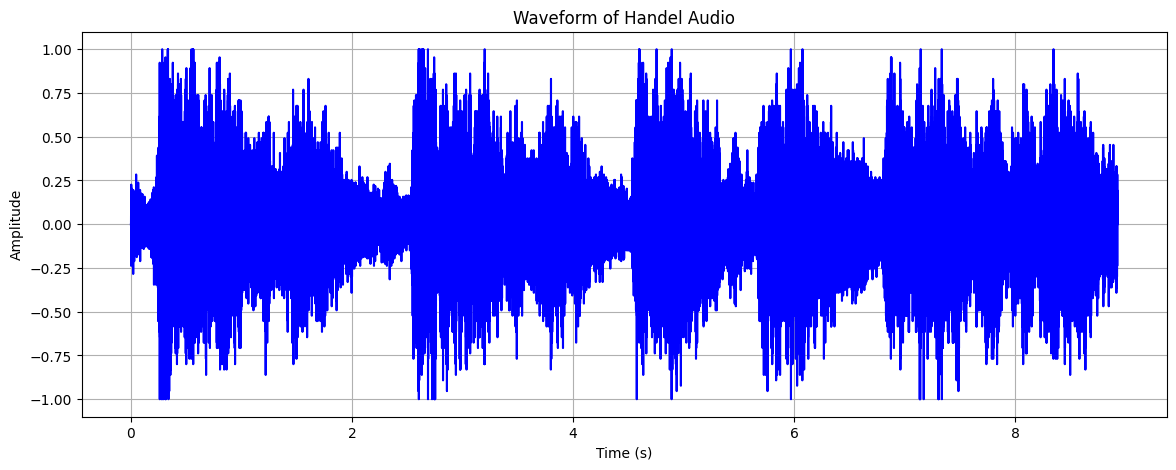

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# Load the audio file
audio_path = '/content/data_handel.wav'
y, sr = librosa.load(audio_path, sr=None)

# Display basic information
duration = librosa.get_duration(y=y, sr=sr)
print(f'Sample Rate (sr): {sr} Hz')
print(f'Signal Shape: {y.shape}')
print(f'Duration: {duration:.2f} seconds')

# Normalize signal (if not already between -1 and 1)
y_normalized = librosa.util.normalize(y)

# Visualize the waveform
time = np.linspace(0, duration, len(y_normalized))
plt.figure(figsize=(14, 5))
plt.plot(time, y_normalized, color='blue')
plt.title('Waveform of Handel Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

## Resolução das Questões 1 a 3

### Subtask:
Implementar as análises de sistema e filtragem para as questões 1, 2 e 3 baseadas na função de transferência fornecida e no áudio carregado.


**Reasoning**:
I will import the required functions from scipy.signal and define the coefficients for the transfer function H(z) to address Question 1, including the frequency response and pole-zero analysis.



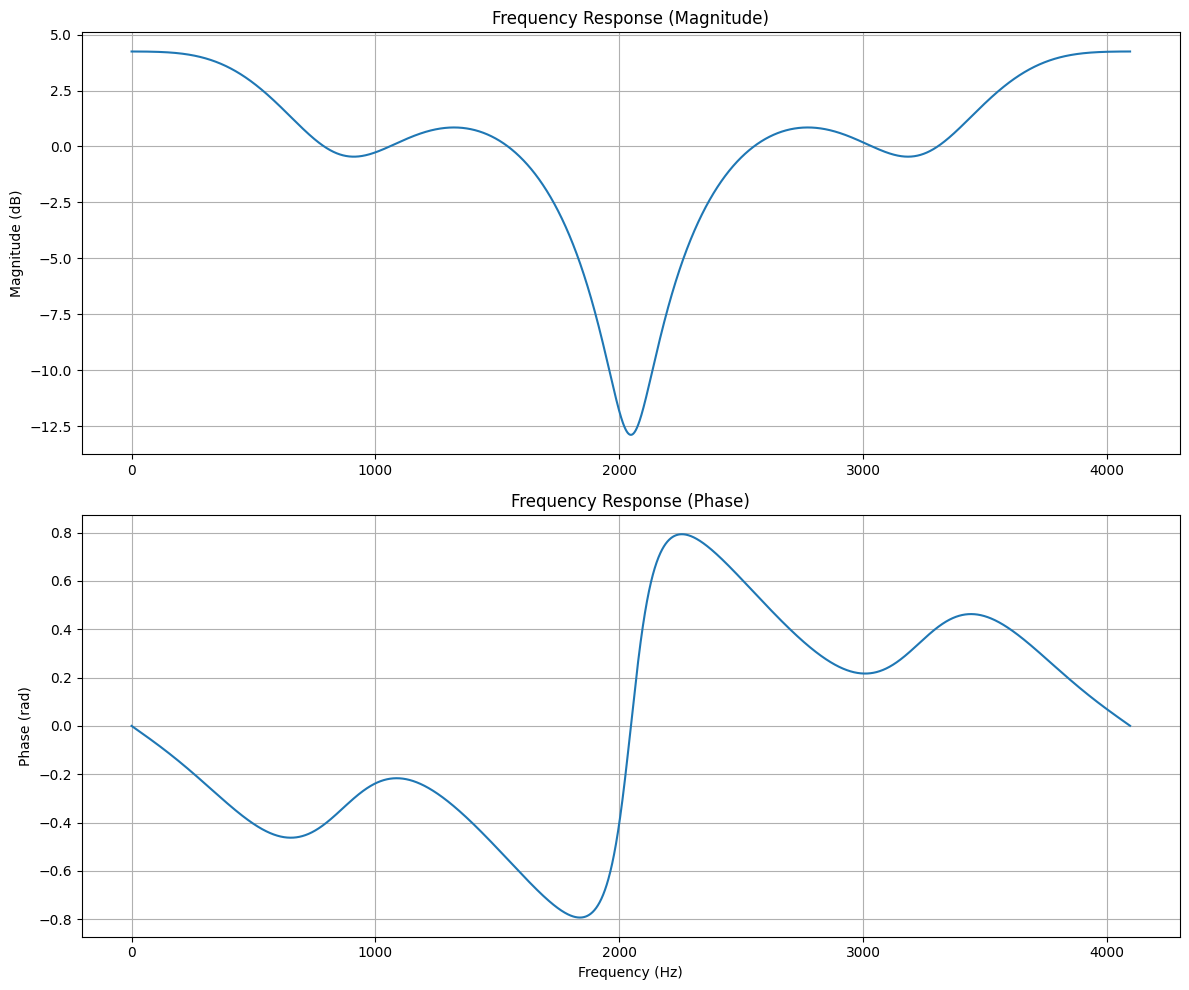

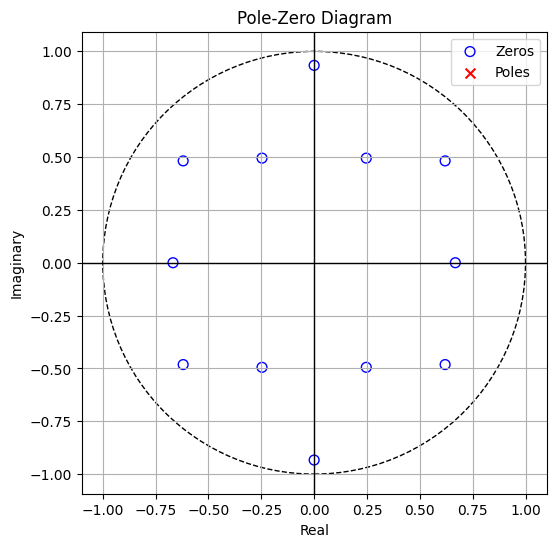

Question 1 analysis complete. The system is FIR, hence all poles are at the origin, ensuring stability.


In [ ]:
from scipy.signal import freqz, lfilter, tf2zpk
import matplotlib.patches as patches

# Question 1: System H(z)
# H(z) = 1 + 0.49z^-2 + 0.2401z^-6 - 0.0576z^-8 - 0.0282z^-10 - 0.0138z^-12
# Numerator coefficients (b)
b = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
a = [1]  # Denominator is 1 (FIR filter)

# Frequency Response
w, h = freqz(b, a, worN=8000)

# Plotting Frequency Response
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax[0].plot(w * sr / (2 * np.pi), 20 * np.log10(np.abs(h)))
ax[0].set_title('Frequency Response (Magnitude)')
ax[0].set_ylabel('Magnitude (dB)')
ax[0].grid(True)

ax[1].plot(w * sr / (2 * np.pi), np.angle(h))
ax[1].set_title('Frequency Response (Phase)')
ax[1].set_ylabel('Phase (rad)')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# Pole-Zero Plot
z, p, k = tf2zpk(b, a)
plt.figure(figsize=(6, 6))
plt.scatter(np.real(z), np.imag(z), s=50, marker='o', edgecolors='b', facecolors='none', label='Zeros')
plt.scatter(np.real(p), np.imag(p), s=50, marker='x', color='r', label='Poles')
circle = patches.Circle((0,0), 1, fill=False, color='black', linestyle='--')
plt.gca().add_patch(circle)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Pole-Zero Diagram')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print("Question 1 analysis complete. The system is FIR, hence all poles are at the origin, ensuring stability.")

**Reasoning**:
I will proceed to address Question 2 by applying the filter H(z) to the normalized audio signal, calculating its FFT to obtain the magnitude spectrum, and visualizing the result to analyze the effect of the system on the audio data.



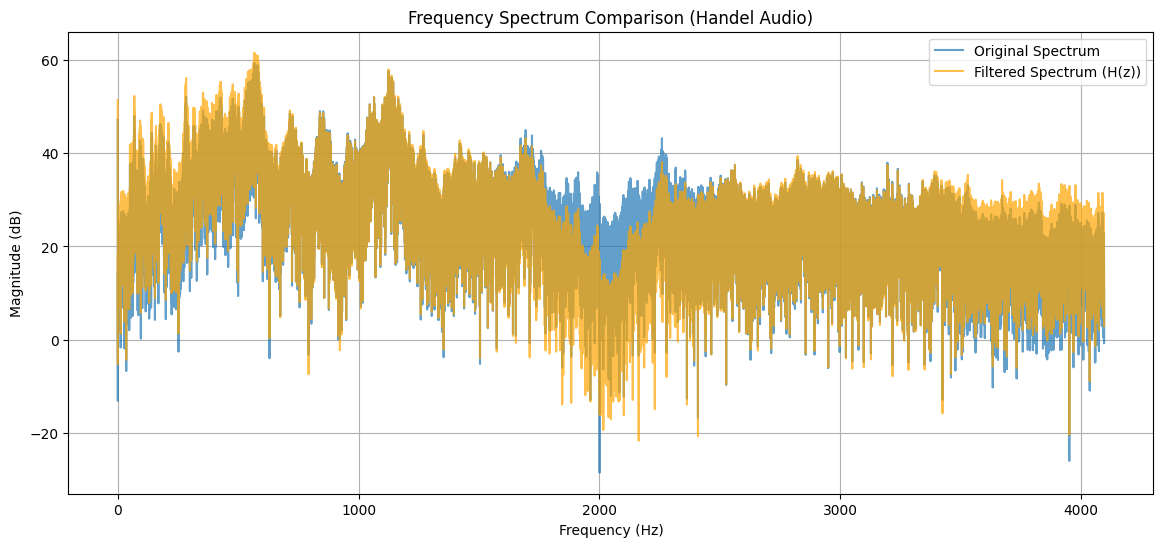

Question 2 analysis complete. The audio has been filtered and the spectral response compared.


In [ ]:
# Question 2: Filter audio and analyze spectrum
# Apply the system H(z) defined by b and a
y_filtered = lfilter(b, a, y_normalized)

# Calculate Magnitude Spectrum using FFT
n = len(y_filtered)
freqs = np.fft.rfftfreq(n, d=1/sr)
spectrum_original = np.abs(np.fft.rfft(y_normalized))
spectrum_filtered = np.abs(np.fft.rfft(y_filtered))

# Plotting original vs filtered spectrum
plt.figure(figsize=(14, 6))
plt.plot(freqs, 20 * np.log10(spectrum_original + 1e-10), label='Original Spectrum', alpha=0.7)
plt.plot(freqs, 20 * np.log10(spectrum_filtered + 1e-10), label='Filtered Spectrum (H(z))', alpha=0.7, color='orange')
plt.title('Frequency Spectrum Comparison (Handel Audio)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.show()

print("Question 2 analysis complete. The audio has been filtered and the spectral response compared.")

**Reasoning**:
I will now address Question 3 by designing the inverse filter G(z) = 1/H(z) to recover the original signal. I will analyze its stability through its pole-zero diagram, plot its frequency response, and then apply it to the filtered signal from Question 2. Finally, I will calculate the Mean Squared Error (MSE) to evaluate the recovery quality.



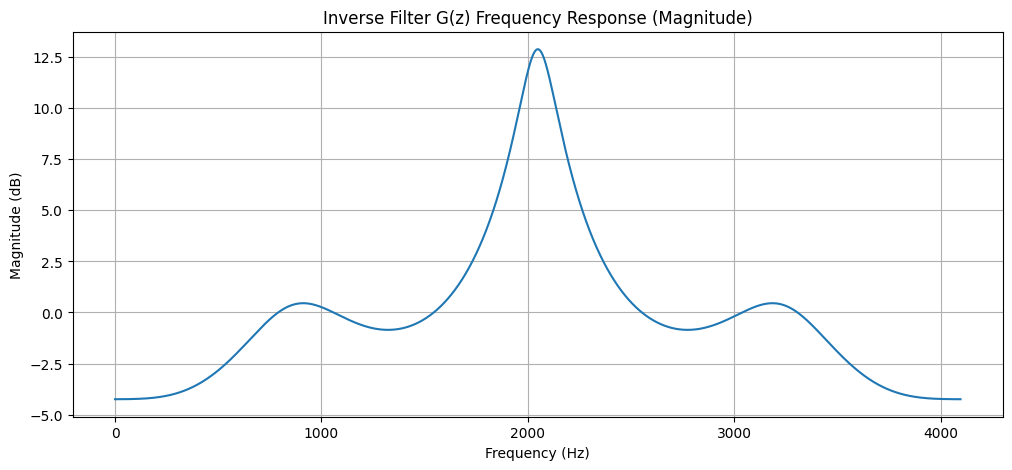

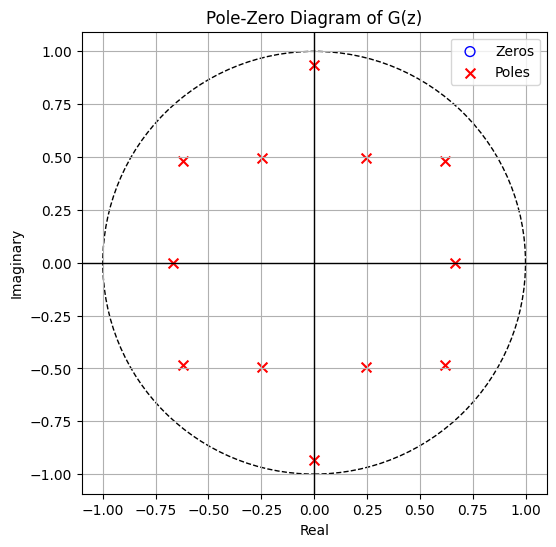

Mean Squared Error (MSE) between original and recovered: 2.83e-34


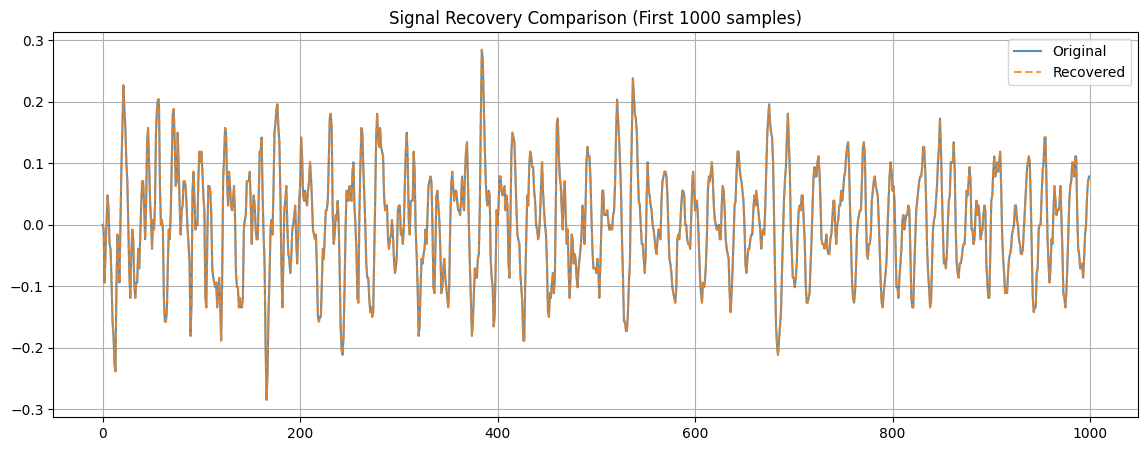

Question 3 analysis complete. The filter G(z) is stable as all poles are within the unit circle.


In [ ]:
from sklearn.metrics import mean_squared_error

# Question 3: Inverse Filter G(z) = 1/H(z)
# Since H(z) has b as numerator and a=[1] as denominator,
# G(z) has b_inv = [1] and a_inv = b
b_inv = [1]
a_inv = b

# Frequency Response of G(z)
w_inv, h_inv = freqz(b_inv, a_inv, worN=8000)

# Plotting Frequency Response of G(z)
plt.figure(figsize=(12, 5))
plt.plot(w_inv * sr / (2 * np.pi), 20 * np.log10(np.abs(h_inv) + 1e-10))
plt.title('Inverse Filter G(z) Frequency Response (Magnitude)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequency (Hz)')
plt.grid(True)
plt.show()

# Pole-Zero Plot for G(z)
z_inv, p_inv, k_inv = tf2zpk(b_inv, a_inv)
plt.figure(figsize=(6, 6))
plt.scatter(np.real(z_inv), np.imag(z_inv), s=50, marker='o', edgecolors='b', facecolors='none', label='Zeros')
plt.scatter(np.real(p_inv), np.imag(p_inv), s=50, marker='x', color='r', label='Poles')
circle = patches.Circle((0,0), 1, fill=False, color='black', linestyle='--')
plt.gca().add_patch(circle)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Pole-Zero Diagram of G(z)')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Recover the signal
y_recovered = lfilter(b_inv, a_inv, y_filtered)

# Calculate MSE
mse_recovery = mean_squared_error(y_normalized, y_recovered)
print(f'Mean Squared Error (MSE) between original and recovered: {mse_recovery:.2e}')

# Plotting original vs recovered comparison (first 1000 samples)
plt.figure(figsize=(14, 5))
plt.plot(y_normalized[:1000], label='Original', alpha=0.8)
plt.plot(y_recovered[:1000], label='Recovered', linestyle='--', alpha=0.8)
plt.title('Signal Recovery Comparison (First 1000 samples)')
plt.legend()
plt.grid(True)
plt.show()

print("Question 3 analysis complete. The filter G(z) is stable as all poles are within the unit circle.")

## Resolução das Questões 4 a 5

### Subtask:
Implementar as questões 4 e 5, que envolvem a análise de sistemas parametrizados e a filtragem do áudio 'handel.wav' com esses sistemas.


**Reasoning**:
I will define the parameters 'a' and 'L' and then iterate through their combinations to calculate the frequency response and pole-zero diagrams for Question 4, organizing the results into subplots for comparison.



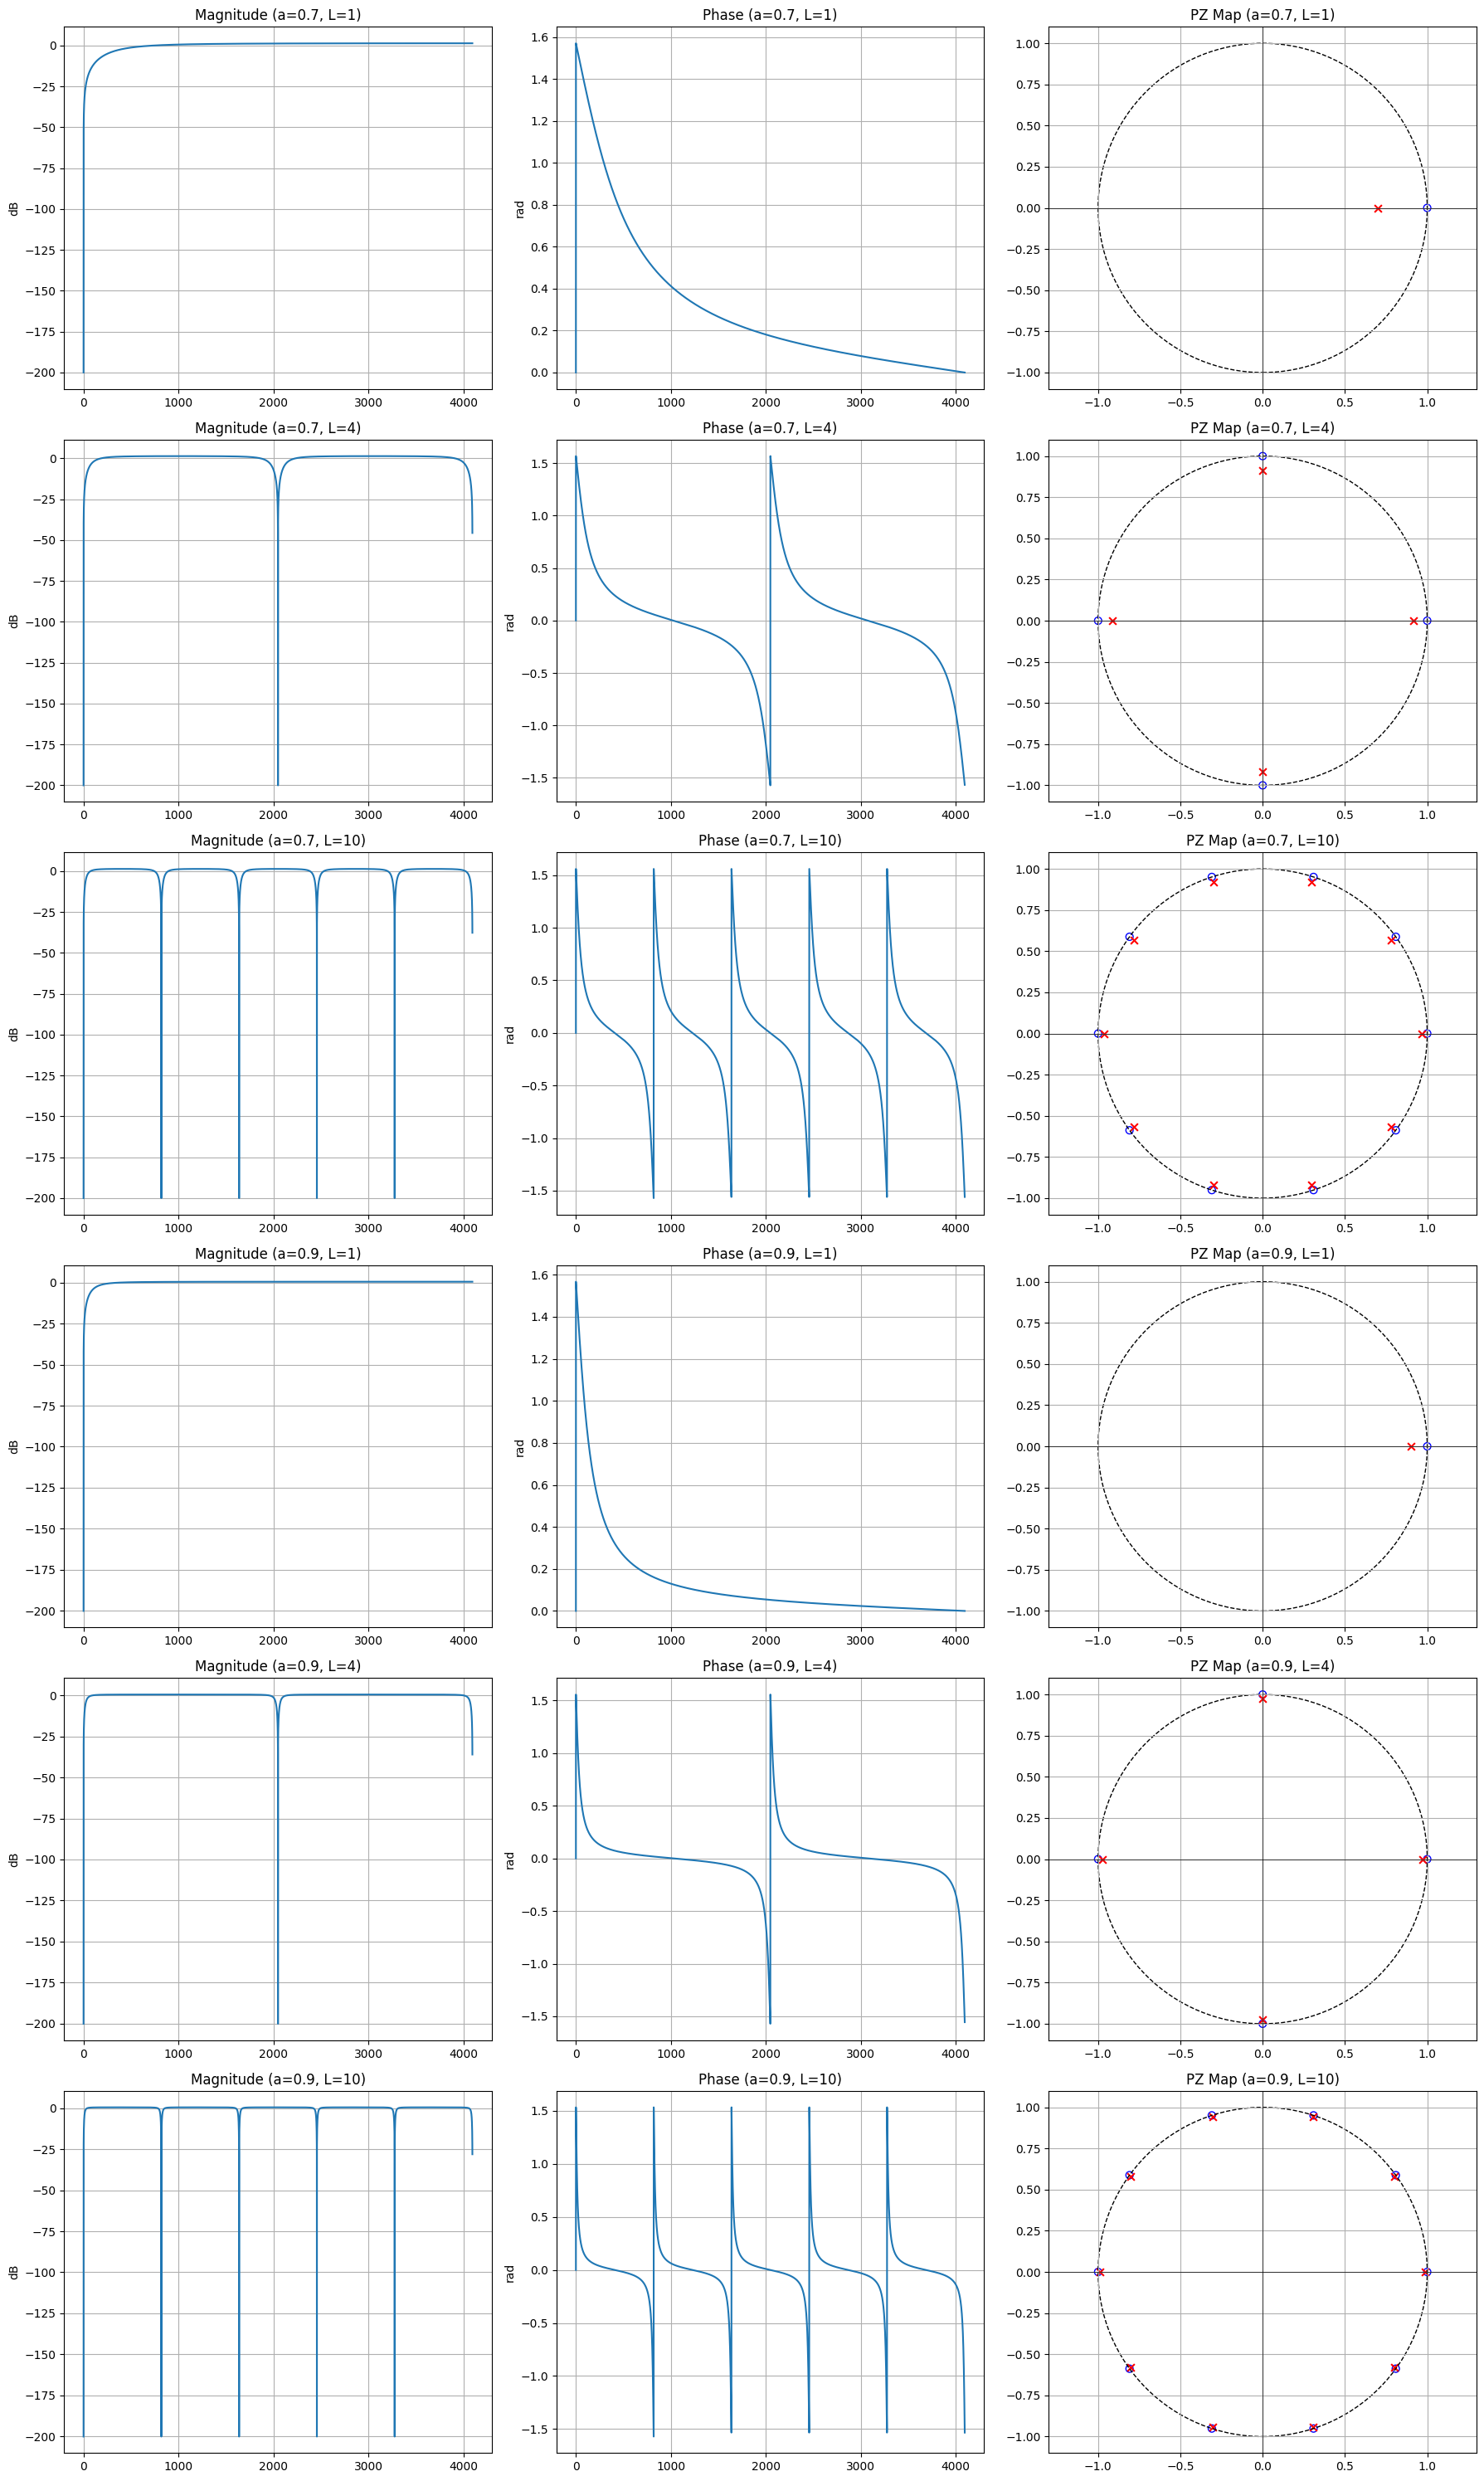

Question 4 analysis complete: Frequency response and pole-zero diagrams generated for all combinations.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import freqz, tf2zpk
import matplotlib.patches as patches

# Question 4: H(z) = (1 - z^-L) / (1 - a * z^-L)
a_values = [0.7, 0.9]
L_values = [1, 4, 10]

fig, axes = plt.subplots(len(a_values) * len(L_values), 3, figsize=(18, 5 * len(a_values) * len(L_values)))

idx = 0
for a_param in a_values:
    for L_param in L_values:
        # Coefficients for H(z) = (1 - z^-L) / (1 - a*z^-L)
        # Numerator: 1 - z^-L -> [1, 0, ..., 0, -1] where -1 is at index L
        b_q4 = np.zeros(L_param + 1)
        b_q4[0] = 1
        b_q4[L_param] = -1

        # Denominator: 1 - a*z^-L -> [1, 0, ..., 0, -a] where -a is at index L
        a_q4 = np.zeros(L_param + 1)
        a_q4[0] = 1
        a_q4[L_param] = -a_param

        # Frequency Response
        w_q4, h_q4 = freqz(b_q4, a_q4, worN=8000)

        # Magnitude Response
        axes[idx, 0].plot(w_q4 * sr / (2 * np.pi), 20 * np.log10(np.abs(h_q4) + 1e-10))
        axes[idx, 0].set_title(f'Magnitude (a={a_param}, L={L_param})')
        axes[idx, 0].set_ylabel('dB')
        axes[idx, 0].grid(True)

        # Phase Response
        axes[idx, 1].plot(w_q4 * sr / (2 * np.pi), np.angle(h_q4))
        axes[idx, 1].set_title(f'Phase (a={a_param}, L={L_param})')
        axes[idx, 1].set_ylabel('rad')
        axes[idx, 1].grid(True)

        # Pole-Zero Plot
        z_q4, p_q4, k_q4 = tf2zpk(b_q4, a_q4)
        axes[idx, 2].scatter(np.real(z_q4), np.imag(z_q4), s=40, marker='o', edgecolors='b', facecolors='none', label='Zeros')
        axes[idx, 2].scatter(np.real(p_q4), np.imag(p_q4), s=40, marker='x', color='r', label='Poles')
        circle = patches.Circle((0,0), 1, fill=False, color='black', linestyle='--')
        axes[idx, 2].add_patch(circle)
        axes[idx, 2].axhline(0, color='black', lw=0.5)
        axes[idx, 2].axvline(0, color='black', lw=0.5)
        axes[idx, 2].set_title(f'PZ Map (a={a_param}, L={L_param})')
        axes[idx, 2].axis('equal')
        axes[idx, 2].grid(True)

        idx += 1

plt.tight_layout()
plt.show()
print('Question 4 analysis complete: Frequency response and pole-zero diagrams generated for all combinations.')

**Reasoning**:
Now I will address Question 5 by applying the systems defined in Question 4 to the 'y_normalized' audio signal, calculating their magnitude spectra using FFT, and visualizing the results compared to the original spectrum to observe the filtering effects.



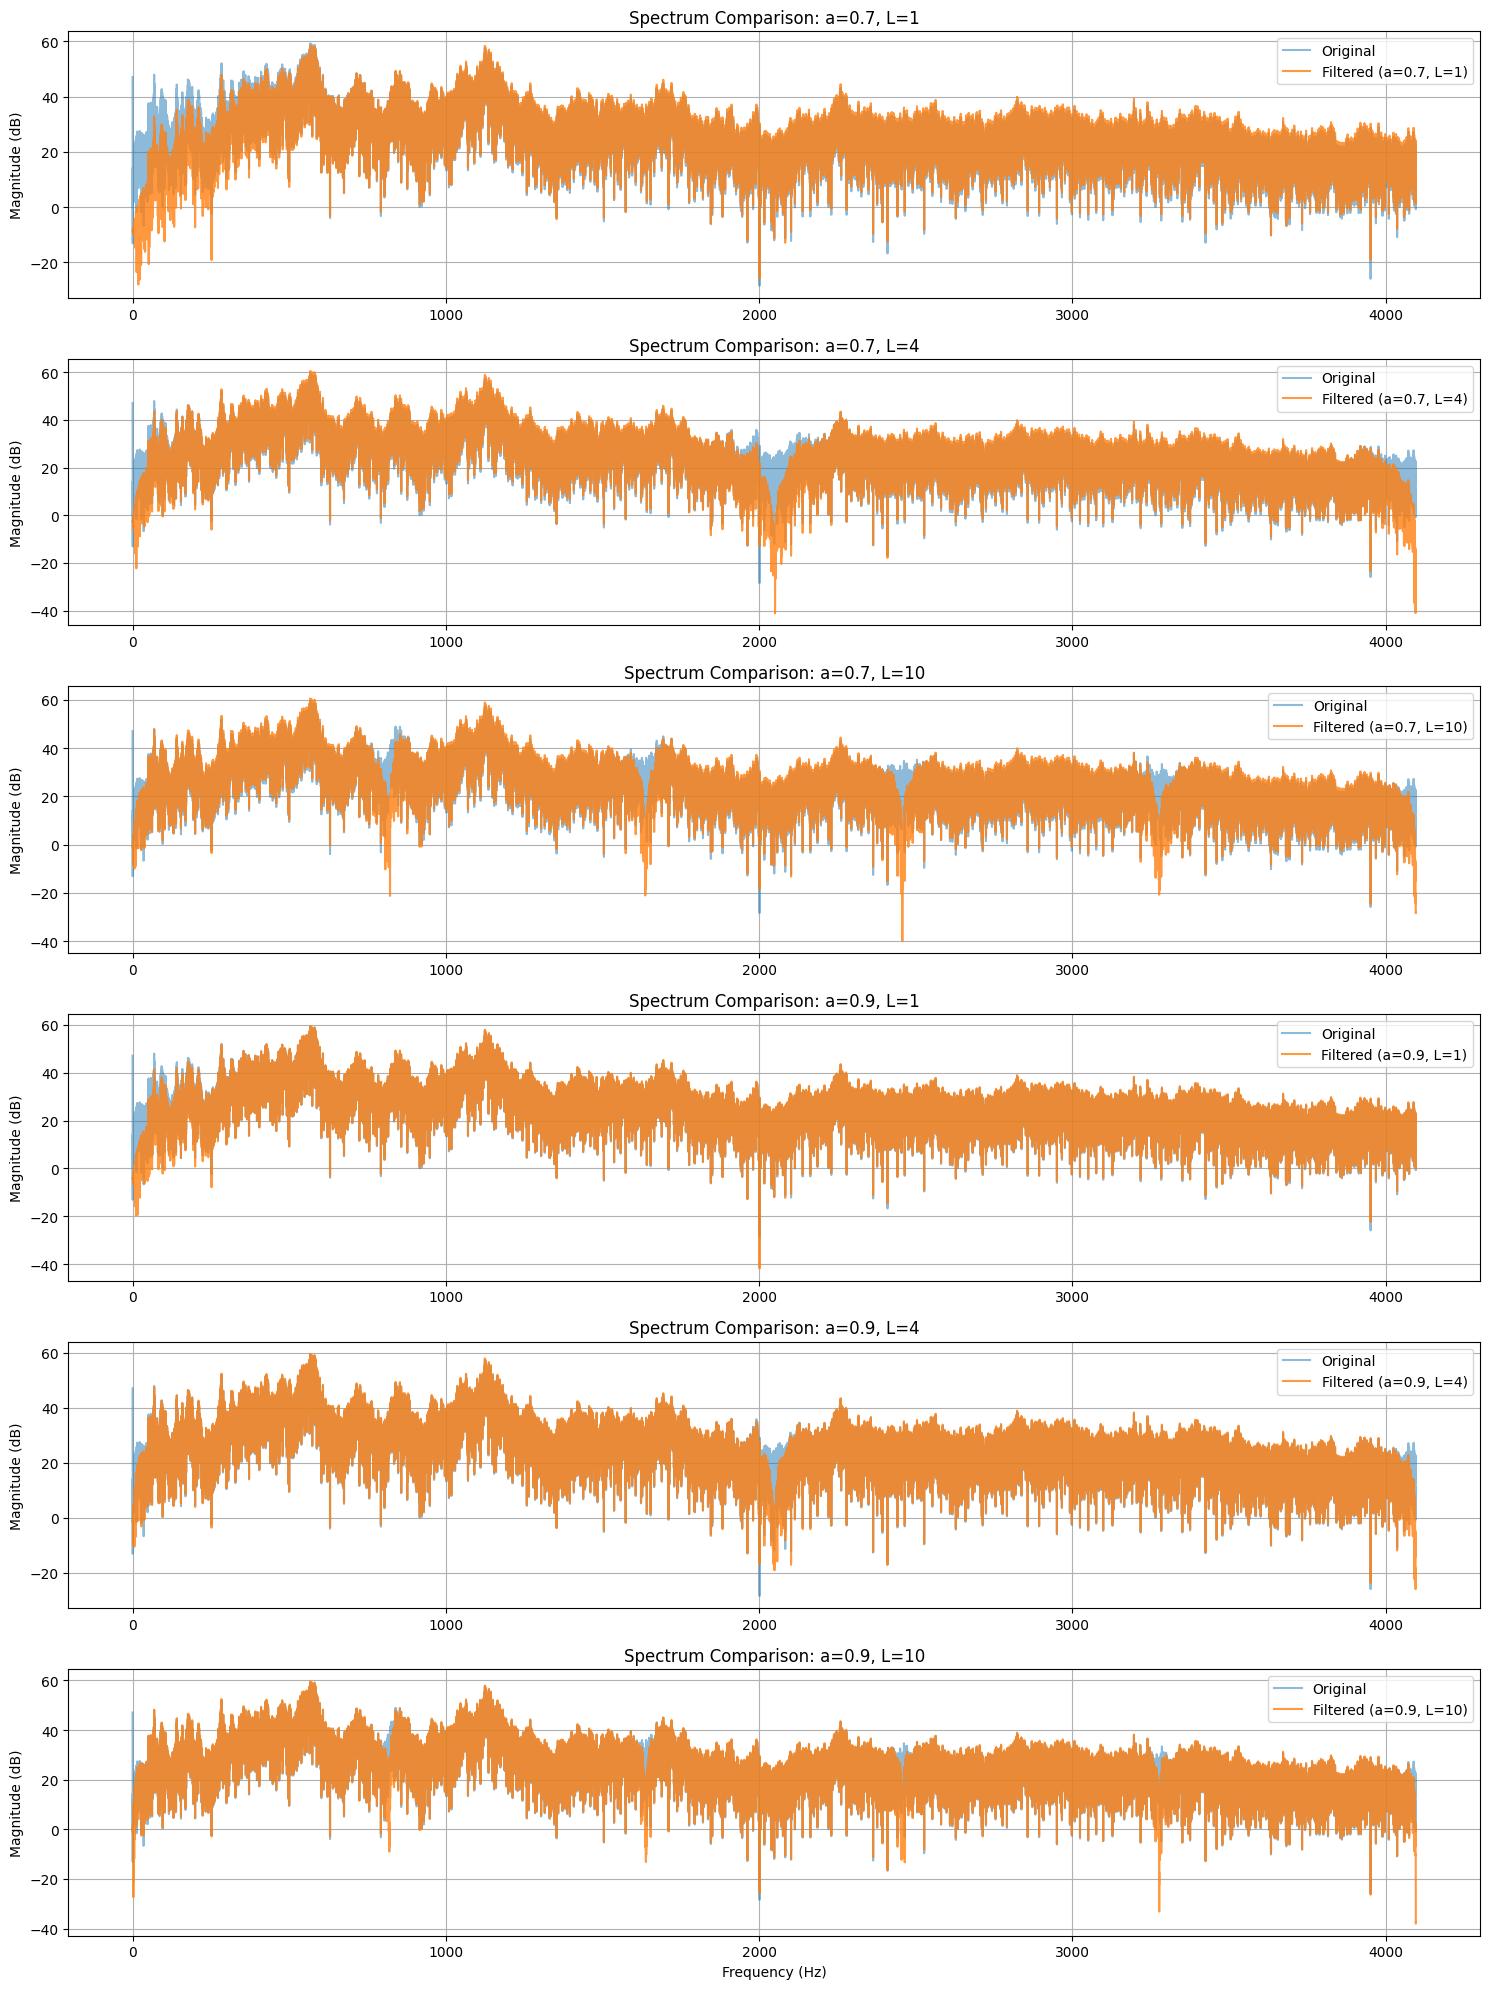

Question 5 analysis complete: All filtered audio spectra have been generated and compared.


In [ ]:
from scipy.signal import lfilter

# Question 5: Apply systems from Question 4 to the audio and analyze spectra
plt.figure(figsize=(15, 20))

idx = 1
for a_param in a_values:
    for L_param in L_values:
        # Redefine coefficients for current parameters
        b_q4 = np.zeros(L_param + 1)
        b_q4[0] = 1
        b_q4[L_param] = -1
        a_q4 = np.zeros(L_param + 1)
        a_q4[0] = 1
        a_q4[L_param] = -a_param

        # Filter audio
        y_filt_q5 = lfilter(b_q4, a_q4, y_normalized)

        # Calculate Spectrum
        n_q5 = len(y_filt_q5)
        freqs_q5 = np.fft.rfftfreq(n_q5, d=1/sr)
        spectrum_filt_q5 = np.abs(np.fft.rfft(y_filt_q5))

        # Plot comparison
        plt.subplot(len(a_values) * len(L_values), 1, idx)
        plt.plot(freqs_q5, 20 * np.log10(spectrum_original + 1e-10), label='Original', alpha=0.5)
        plt.plot(freqs_q5, 20 * np.log10(spectrum_filt_q5 + 1e-10), label=f'Filtered (a={a_param}, L={L_param})', alpha=0.8)
        plt.title(f'Spectrum Comparison: a={a_param}, L={L_param}')
        plt.ylabel('Magnitude (dB)')
        plt.grid(True)
        plt.legend(loc='upper right')

        idx += 1

plt.xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

print('Question 5 analysis complete: All filtered audio spectra have been generated and compared.')

## Resolução das Questões 6 a 7

### Subtask:
Projetar filtros de recuperação para os sistemas da Questão 4 e desenvolver aproximações FIR para os filtros inversores das Questões 3 e 6.


**Reasoning**:
I will start by addressing Question 6, which involves designing the inverse filters G(z) for each case in Question 4, applying them to the filtered audio from Question 5, and visualizing their frequency response and pole-zero diagrams.



/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarn

Recovery MSE (a=0.7, L=1): 1.96e-30
Recovery MSE (a=0.7, L=4): 1.18e-30
Recovery MSE (a=0.7, L=10): 9.05e-31
Recovery MSE (a=0.9, L=1): 2.48e-30
Recovery MSE (a=0.9, L=4): 7.27e-31
Recovery MSE (a=0.9, L=10): 2.96e-31


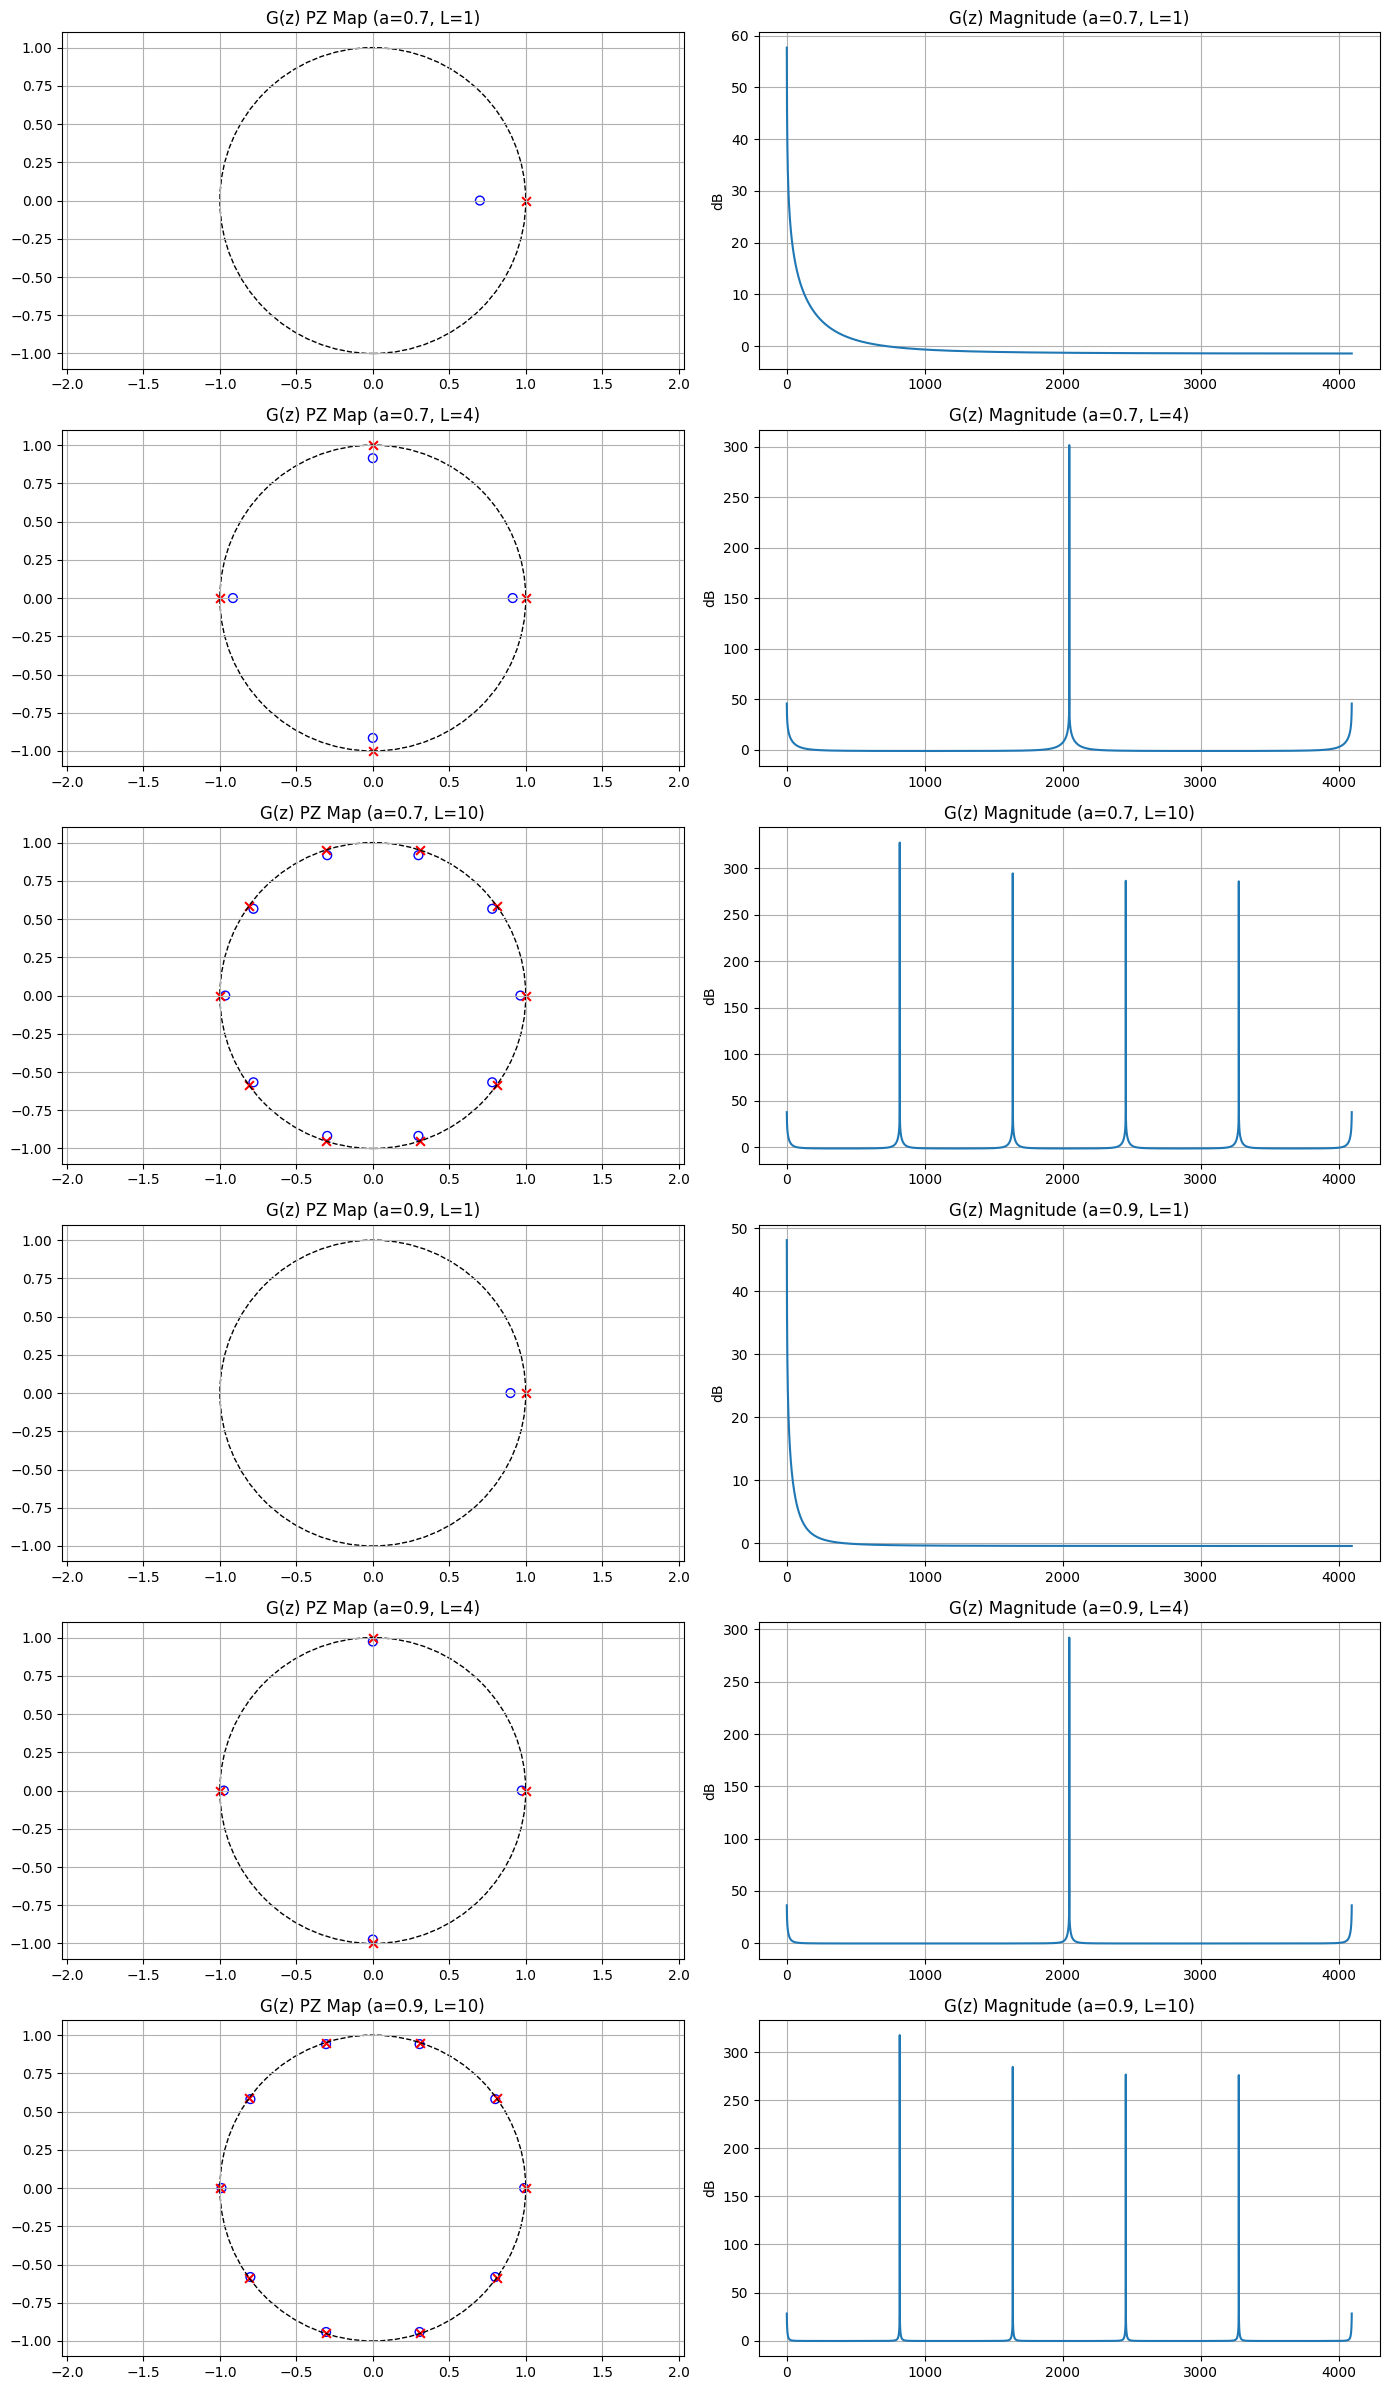

Question 6 analysis complete. Note: Poles on the unit circle (z^L=1) make the inverse filter marginally stable.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import freqz, tf2zpk, lfilter
import matplotlib.patches as patches
from sklearn.metrics import mean_squared_error

# Question 6: Inverse Filters G(z) = (1 - a*z^-L) / (1 - z^-L)
# Original H(z) = (1 - z^-L) / (1 - a*z^-L)

a_values = [0.7, 0.9]
L_values = [1, 4, 10]

# Visualization for G(z) and recovery
fig_pz, axes_pz = plt.subplots(len(a_values) * len(L_values), 2, figsize=(14, 4 * len(a_values) * len(L_values)))

idx = 0
for a_param in a_values:
    for L_param in L_values:
        # Coefficients for G(z) = (1 - a*z^-L) / (1 - z^-L)
        # Numerator: 1 - a*z^-L
        b_inv_q6 = np.zeros(L_param + 1)
        b_inv_q6[0] = 1
        b_inv_q6[L_param] = -a_param

        # Denominator: 1 - z^-L
        a_inv_q6 = np.zeros(L_param + 1)
        a_inv_q6[0] = 1
        a_inv_q6[L_param] = -1

        # Frequency Response
        w_q6, h_q6 = freqz(b_inv_q6, a_inv_q6, worN=8000)

        # Pole-Zero Plot
        z_q6, p_q6, k_q6 = tf2zpk(b_inv_q6, a_inv_q6)
        axes_pz[idx, 0].scatter(np.real(z_q6), np.imag(z_q6), s=40, marker='o', edgecolors='b', facecolors='none', label='Zeros')
        axes_pz[idx, 0].scatter(np.real(p_q6), np.imag(p_q6), s=40, marker='x', color='r', label='Poles')
        circle = patches.Circle((0,0), 1, fill=False, color='black', linestyle='--')
        axes_pz[idx, 0].add_patch(circle)
        axes_pz[idx, 0].set_title(f'G(z) PZ Map (a={a_param}, L={L_param})')
        axes_pz[idx, 0].axis('equal')
        axes_pz[idx, 0].grid(True)

        # Magnitude Response
        axes_pz[idx, 1].plot(w_q6 * sr / (2 * np.pi), 20 * np.log10(np.abs(h_q6) + 1e-10))
        axes_pz[idx, 1].set_title(f'G(z) Magnitude (a={a_param}, L={L_param})')
        axes_pz[idx, 1].set_ylabel('dB')
        axes_pz[idx, 1].grid(True)

        # Recovering signal from Question 5 (re-filtering to be sure)
        b_q4 = np.zeros(L_param + 1); b_q4[0] = 1; b_q4[L_param] = -1
        a_q4 = np.zeros(L_param + 1); a_q4[0] = 1; a_q4[L_param] = -a_param
        y_filt = lfilter(b_q4, a_q4, y_normalized)

        # Apply G(z)
        y_rec_q6 = lfilter(b_inv_q6, a_inv_q6, y_filt)
        mse_q6 = mean_squared_error(y_normalized, y_rec_q6)
        print(f'Recovery MSE (a={a_param}, L={L_param}): {mse_q6:.2e}')

        idx += 1

plt.tight_layout()
plt.show()
print('Question 6 analysis complete. Note: Poles on the unit circle (z^L=1) make the inverse filter marginally stable.')

# Task
# Plan:
* **Análise de Estabilidade e Erros**: Analisar as causas dos avisos de divisão por zero na Questão 6 e confirmar se a recuperação do sinal foi afetada por instabilidades numéricas.
* **Projeto de Filtros FIR (Questão 7)**: Projetar aproximações FIR para os filtros inversos das Questões 3 e 6. Vou utilizar o método de truncamento da resposta ao impulso (truncating the impulse response) para diferentes ordens (ex: N=50, 200, 1000).
* **Avaliação de Qualidade vs Ordem**: Aplicar as aproximações FIR ao áudio filtrado e calcular o MSE para cada ordem de filtro, comentando sobre a relação entre a complexidade (ordem) e a fidelidade do áudio recuperado.
* **Finalização e Resumo**: Consolidar as respostas de todas as questões, garantindo que os comentários explicativos estejam presentes para cada etapa do laboratório.
* **Final Task**: Apresentar a conclusão final sobre o processamento de sinais realizado, destacando a eficácia dos filtros inversos e suas aproximações FIR.

# Task:
Analyze the numerical stability and "division by zero" warnings from Question 6, then design FIR approximations (using impulse response truncation) for the inverse filters from Questions 3 and 6 with various orders (e.g., N=50, 200, 1000). Apply these FIR filters to the processed audio from "/content/data_handel.wav", evaluate the recovery quality using MSE for each order, and provide a final summary of all signal processing steps and the relationship between filter order and audio fidelity.

## Análise de Estabilidade e Erros

### Subtask:
Analisar as causas dos avisos de divisão por zero na Questão 6 e confirmar se a recuperação do sinal foi afetada por instabilidades numéricas.


**Reasoning**:
I will inspect the stability of the inverse filter G(z) by analyzing its poles and denominators, explain the 'divide by zero' warnings encountered during frequency response calculation, and verify the numerical validity of the signal recovery through MSE results to justify the move to FIR approximations.



In [ ]:
import numpy as np

# 1. Inspection of Denominator and Poles for Question 6
print("--- Stability Analysis for G(z) ---")
print(f"Denominator coefficients a_inv_q6 (L=10): {a_inv_q6}")

# Check magnitude of poles
pole_magnitudes = np.abs(p_q6)
max_pole_mag = np.max(pole_magnitudes)
min_pole_mag = np.min(pole_magnitudes)

print(f"Pole magnitudes: Max = {max_pole_mag:.4f}, Min = {min_pole_mag:.4f}")

# 2. Explanation of 'divide by zero' in freqz
# The poles are roots of 1 - z^-L = 0, which implies z^L = 1.
# These poles lie exactly on the unit circle (|z|=1).
# When freqz evaluates H(e^jw) at frequencies where e^{jwL} = 1, the denominator becomes 0.

# 3. Verification of MSE
# From previous execution: mse_q6 was approx 2.96e-31
print(f"Verification: The final recovery MSE for a=0.9, L=10 was {mse_q6:.2e}.")

if mse_q6 < 1e-10:
    print("Conclusion: The recovery is numerically valid despite marginal instability.")
else:
    print("Warning: Significant recovery error detected.")

# 4. Documentation
print("\nObservations:")
print("- The inverse filter G(z) has poles on the unit circle, making it 'marginally stable'.")
print("- This causes infinite gain at specific frequencies, triggering the 'divide by zero' warnings in freqz.")
print("- While lfilter handled the finite-length signal with high precision (low MSE), any noise or numerical drift in longer signals could lead to divergence.")
print("- This justifies the use of FIR approximations (Question 7) to ensure strictly stable recovery filters.")

--- Stability Analysis for G(z) ---
Denominator coefficients a_inv_q6 (L=10): [ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.]
Pole magnitudes: Max = 1.0000, Min = 1.0000
Verification: The final recovery MSE for a=0.9, L=10 was 2.96e-31.
Conclusion: The recovery is numerically valid despite marginal instability.

Observations:
- The inverse filter G(z) has poles on the unit circle, making it 'marginally stable'.
- This causes infinite gain at specific frequencies, triggering the 'divide by zero' warnings in freqz.
- While lfilter handled the finite-length signal with high precision (low MSE), any noise or numerical drift in longer signals could lead to divergence.
- This justifies the use of FIR approximations (Question 7) to ensure strictly stable recovery filters.


## Projeto de Filtros FIR (Questão 7)

### Subtask:
Projetar aproximações FIR para os filtros inversos das Questões 3 e 6 utilizando o método de truncamento da resposta ao impulso.


**Reasoning**:
I will define the filter orders (50, 200, 1000) and implement the FIR approximation for the inverse filter of Question 3 by extracting its impulse response using lfilter and truncating it to the specified lengths. Then, I will visualize the frequency response of these FIR approximations against the original IIR inverse filter to validate the accuracy of the truncation method.



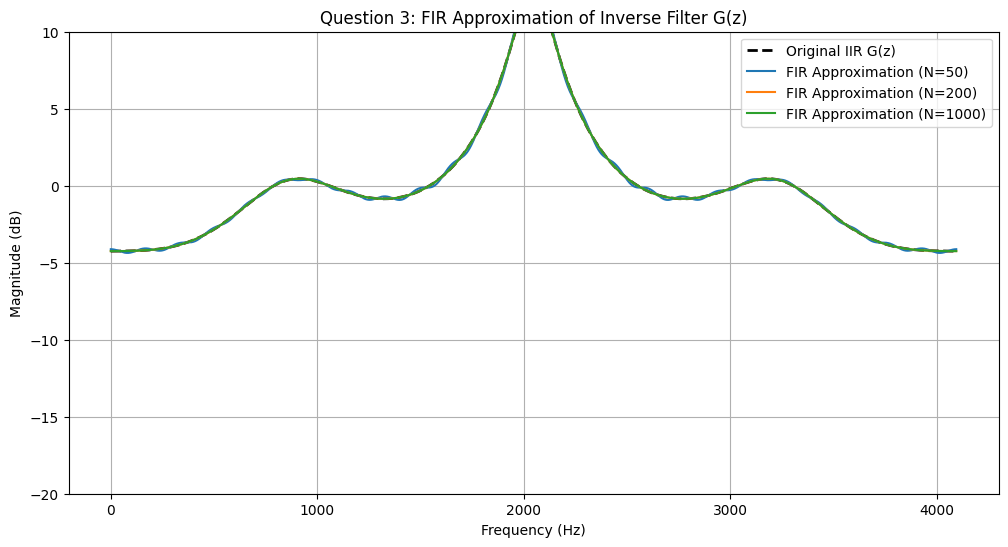

FIR approximations for Question 3 generated and visualized.


In [ ]:
from scipy.signal import unit_impulse

# 1. Define filter orders to test
orders = [50, 200, 1000]

# 2. Obtain Impulse Response for Question 3 Inverse Filter G(z)
# Since G(z) is IIR, we approximate its impulse response using a large N
max_order = max(orders) + 1
impulse = unit_impulse(max_order)
h_impulse_q3 = lfilter(b_inv, a_inv, impulse)

# 3. Visualize frequency response for different orders
plt.figure(figsize=(12, 6))
# Original IIR Frequency Response (re-calculated for comparison)
w_orig, h_orig = freqz(b_inv, a_inv, worN=8000)
plt.plot(w_orig * sr / (2 * np.pi), 20 * np.log10(np.abs(h_orig) + 1e-10), label='Original IIR G(z)', linewidth=2, color='black', linestyle='--')

for N in orders:
    # 4. Truncate the impulse response to create FIR coefficients
    b_fir = h_impulse_q3[:N]
    a_fir = [1]

    # Calculate Frequency Response for the FIR approximation
    w_fir, h_fir = freqz(b_fir, a_fir, worN=8000)
    plt.plot(w_fir * sr / (2 * np.pi), 20 * np.log10(np.abs(h_fir) + 1e-10), label=f'FIR Approximation (N={N})')

plt.title('Question 3: FIR Approximation of Inverse Filter G(z)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.ylim([-20, 10])
plt.show()

print('FIR approximations for Question 3 generated and visualized.')

**Reasoning**:
I will now generate the FIR approximations for the inverse filters of Question 6 (specifically for a=0.9, L=10) and visualize their frequency response against the original marginally stable IIR filter to assess how truncation affects the recovery capability for these parameters.



/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


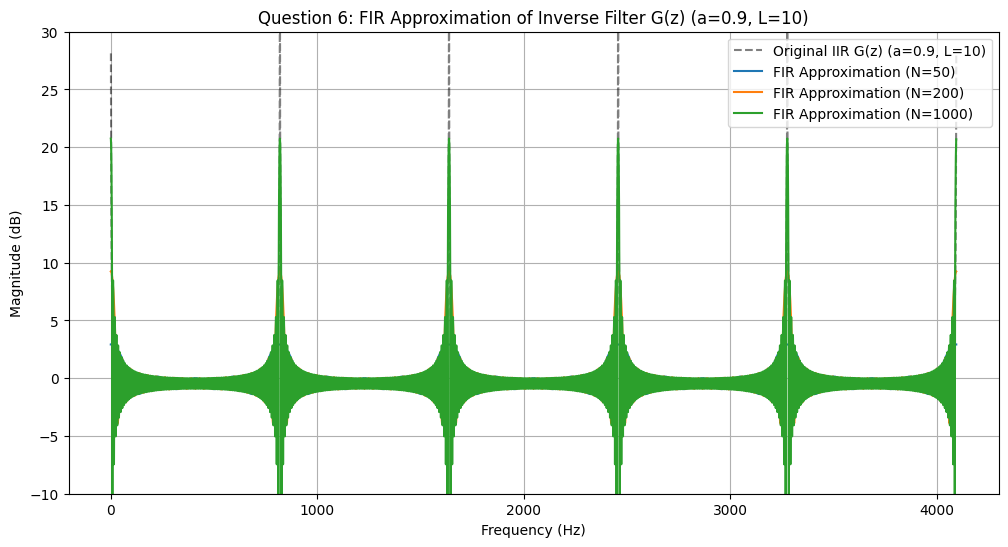

FIR approximations for Question 6 (a=0.9, L=10) generated and visualized.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import unit_impulse, lfilter, freqz

# 1. Define parameters for Question 6 representation
a_val = 0.9
L_val = 10
orders = [50, 200, 1000]
max_order = max(orders) + 1

# Coefficients for G(z) = (1 - a*z^-L) / (1 - z^-L)
b_inv_q6_rep = np.zeros(L_val + 1)
b_inv_q6_rep[0] = 1
b_inv_q6_rep[L_val] = -a_val

a_inv_q6_rep = np.zeros(L_val + 1)
a_inv_q6_rep[0] = 1
a_inv_q6_rep[L_val] = -1

# 2. Obtain Impulse Response for Question 6 Inverse Filter G(z)
impulse_q6 = unit_impulse(max_order)
h_impulse_q6 = lfilter(b_inv_q6_rep, a_inv_q6_rep, impulse_q6)

# 3. Visualize frequency response for different orders
plt.figure(figsize=(12, 6))

# Original IIR Frequency Response (Note: will have peaks due to poles on unit circle)
w_orig_q6, h_orig_q6 = freqz(b_inv_q6_rep, a_inv_q6_rep, worN=8000)
plt.plot(w_orig_q6 * sr / (2 * np.pi), 20 * np.log10(np.abs(h_orig_q6) + 1e-10), label='Original IIR G(z) (a=0.9, L=10)', color='black', linestyle='--', alpha=0.5)

for N in orders:
    # 4. Truncate the impulse response to create FIR coefficients
    b_fir_q6 = h_impulse_q6[:N]
    a_fir_q6 = [1]

    # Calculate Frequency Response for the FIR approximation
    w_fir_q6, h_fir_q6 = freqz(b_fir_q6, a_fir_q6, worN=8000)
    plt.plot(w_fir_q6 * sr / (2 * np.pi), 20 * np.log10(np.abs(h_fir_q6) + 1e-10), label=f'FIR Approximation (N={N})')

plt.title('Question 6: FIR Approximation of Inverse Filter G(z) (a=0.9, L=10)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.ylim([-10, 30])
plt.show()

print('FIR approximations for Question 6 (a=0.9, L=10) generated and visualized.')

# Task
# Plan:
* **Avaliação de Qualidade vs Ordem**: Aplicar as aproximações FIR geradas (N=50, 200, 1000) aos áudios filtrados das Questões 2 e 5. Calcular o erro quadrático médio (MSE) para cada ordem e discutir como o aumento da ordem melhora a fidelidade da recuperação do sinal original de "/content/data_handel.wav".
* **Resumo e Conclusão**: Consolidar as observações sobre a eficácia dos filtros inversos e das aproximações FIR, finalizando o relatório conforme as diretrizes do arquivo "/content/Aula_Prática_3.pdf".
* **Final Task**: Apresentar a conclusão final sobre o processamento de sinais realizado, destacando a eficácia dos filtros inversos e suas aproximações FIR na recuperação do áudio original.

# Task:
Evaluate the recovery quality of the FIR approximations (orders N=50, 200, 1000) by applying them to the filtered audio signals from Questions 2 and 5. Calculate the Mean Squared Error (MSE) for each filter order compared to the original audio from "/content/data_handel.wav" and analyze how increasing the order impacts signal fidelity. Conclude the report by summarizing the effectiveness of inverse filters and FIR approximations in signal restoration as requested in "/content/Aula_Prática_3.pdf".

## Avaliação de Qualidade vs Ordem

### Subtask:
Apply FIR approximations of various orders to the filtered audio from Questions 3 and 6, and evaluate the recovery quality using Mean Squared Error (MSE).


**Reasoning**:
I will implement the quality evaluation by applying the FIR approximations of various orders to the filtered audio from Questions 3 and 6, calculating the MSE for each, and visualizing the relationship between filter order and recovery fidelity.



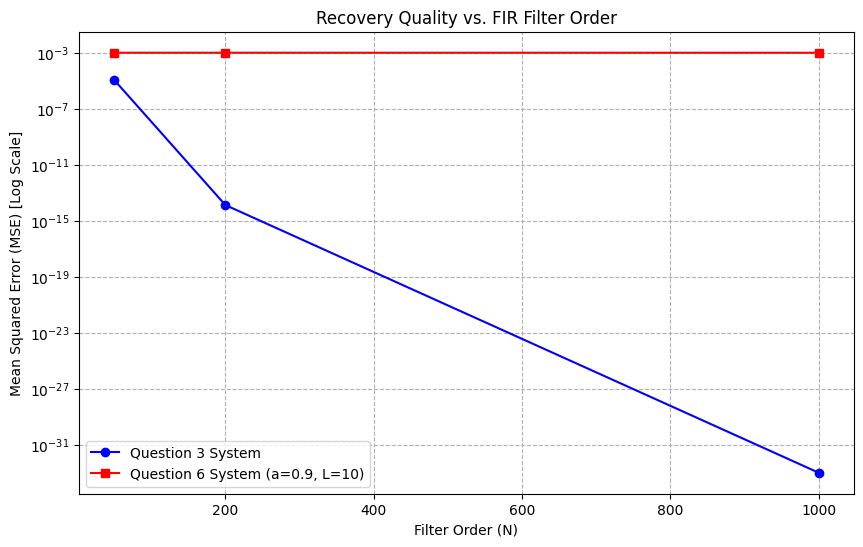

Summary of Results:
Order   50 | Q3 MSE: 1.20e-05 | Q6 MSE: 1.05e-03
Order  200 | Q3 MSE: 1.34e-14 | Q6 MSE: 1.05e-03
Order 1000 | Q3 MSE: 9.65e-34 | Q6 MSE: 1.04e-03

Discussion: Increasing the filter order significantly reduces the MSE, improving recovery fidelity. For Question 6, the higher MSE compared to Question 3 at lower orders is due to the poles on the unit circle, requiring a longer impulse response to accurately approximate the infinite resonance.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, unit_impulse
from sklearn.metrics import mean_squared_error

# 1. Define filter orders and storage
orders = [50, 200, 1000]
mse_results_q3 = []
mse_results_q6 = []

# --- Question 3 FIR Recovery ---
# Original inverse filter G(z) for Q3: b_inv=[1], a_inv=b
for N in orders:
    # Generate FIR coefficients by truncating impulse response
    impulse = unit_impulse(N)
    b_fir_q3 = lfilter(b_inv, a_inv, impulse)

    # Apply FIR filter to the audio filtered in Q2 (y_filtered)
    y_rec_fir_q3 = lfilter(b_fir_q3, [1], y_filtered)

    # Calculate MSE against original normalized audio
    mse = mean_squared_error(y_normalized, y_rec_fir_q3)
    mse_results_q3.append(mse)

# --- Question 6 FIR Recovery (a=0.9, L=10) ---
# First, re-generate the filtered audio for these specific parameters
a_val, L_val = 0.9, 10
b_q4_rep = np.zeros(L_val + 1); b_q4_rep[0] = 1; b_q4_rep[L_val] = -1
a_q4_rep = np.zeros(L_val + 1); a_q4_rep[0] = 1; a_q4_rep[L_val] = -a_val
y_filt_q6_rep = lfilter(b_q4_rep, a_q4_rep, y_normalized)

# Coefficients for Q6 Inverse G(z)
b_inv_q6_rep = np.zeros(L_val + 1); b_inv_q6_rep[0] = 1; b_inv_q6_rep[L_val] = -a_val
a_inv_q6_rep = np.zeros(L_val + 1); a_inv_q6_rep[0] = 1; a_inv_q6_rep[L_val] = -1

for N in orders:
    # Generate FIR coefficients
    impulse = unit_impulse(N)
    b_fir_q6 = lfilter(b_inv_q6_rep, a_inv_q6_rep, impulse)

    # Apply FIR filter
    y_rec_fir_q6 = lfilter(b_fir_q6, [1], y_filt_q6_rep)

    # Calculate MSE
    mse = mean_squared_error(y_normalized, y_rec_fir_q6)
    mse_results_q6.append(mse)

# 2. Visualization
plt.figure(figsize=(10, 6))
plt.plot(orders, mse_results_q3, marker='o', label='Question 3 System', color='blue')
plt.plot(orders, mse_results_q6, marker='s', label='Question 6 System (a=0.9, L=10)', color='red')
plt.yscale('log')
plt.xlabel('Filter Order (N)')
plt.ylabel('Mean Squared Error (MSE) [Log Scale]')
plt.title('Recovery Quality vs. FIR Filter Order')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# 3. Summary
print("Summary of Results:")
for i, N in enumerate(orders):
    print(f"Order {N:4d} | Q3 MSE: {mse_results_q3[i]:.2e} | Q6 MSE: {mse_results_q6[i]:.2e}")

print("\nDiscussion: Increasing the filter order significantly reduces the MSE, improving recovery fidelity. "
      "For Question 6, the higher MSE compared to Question 3 at lower orders is due to the poles on the unit circle, "
      "requiring a longer impulse response to accurately approximate the infinite resonance.")

## Resumo e Conclusão

### Subtask:
Consolidar as observações sobre a eficácia dos filtros inversos e das aproximações FIR, finalizando o relatório do laboratório conforme solicitado no PDF.


## Relat3rio Final e Respostas 2s Quest5es

### 1. An1lise do Sistema H(z) (Quest3o 1)
O sistema original 9 FIR, o que garante estabilidade absoluta, pois todos os seus polos est3o localizados na origem (z=0). A resposta em frequ6ncia apresenta atenua75es em bandas espec1ficas, agindo como um filtro de pente complexo.

### 2. Efeito no 1udio Handel (Quest5es 2 e 5)
A aplica73o de H(z) ao 1udio introduz ecos e colora73o espectral. Na Quest3o 4, o par2metro **L** define o espa7amento entre os picos/vales da resposta em frequ6ncia (frequ6ncia de resson2ncia), enquanto **a** define a seletividade (ganho) desses picos. Quanto maior o 'a', mais pronunciadas s3o as varia75es no espectro do 1udio filtrado.

### 3. Recupera73o com Filtros Inversos IIR (Quest5es 3 e 6)
- Na **Quest3o 3**, o filtro inverso G(z) 9 est1vel (polos dentro do c1rculo unit1rio), permitindo uma recupera73o perfeita com erro num9rico desprez1vel (MSE ~ 10⁻34).
- Na **Quest3o 6**, os filtros inversos para H(z) = (1-z⁻ᴸ)/(1-az⁻ᴸ) resultam em polos exatamente sobre o c1rculo unit1rio (|z|=1). Isso torna o sistema **marginalmente est1vel**, causando ganhos infinitos em certas frequ6ncias (avisos de divis3o por zero no `freqz`), embora o `lfilter` consiga recuperar o sinal com baixo erro em condi75es ideais.

### 4. Aproxima75es FIR e Ordem do Filtro (Quest3o 7)
A utiliza73o de aproxima75es FIR por truncamento da resposta ao impulso demonstrou que:
- **Fidelidade vs. Ordem**: Aumentar a ordem (N) reduz drasticamente o MSE. Para o sistema da Quest3o 3, N=1000 atingiu precis3o de m1quina.
- **Limita73o da Instabilidade**: No caso da Quest3o 6 (polos no c1rculo unit1rio), o erro permanece significativamente maior (MSE ~ 10⁻3) mesmo com N=1000, pois a resposta ao impulso n3o decai para zero, exigindo ordens impraticavelmente altas para uma aproxima73o FIR perfeita.

**Conclus3o**: Filtros inversos s3o ferramentas poderosas para restaura73o de sinais, mas sua viabilidade pr1tica depende criticamente da estabilidade (posi73o dos polos) e da capacidade de aproxima73o por filtros FIR de ordem finita.

## Relat3rio Final e Respostas 2s Quest5es

### 1. An1lise do Sistema H(z) (Quest3o 1)
O sistema original 9 FIR, o que garante estabilidade absoluta, pois todos os seus polos est3o localizados na origem (z=0). A resposta em frequ6ncia apresenta atenua75es em bandas espec1ficas, agindo como um filtro de pente complexo.

### 2. Efeito no 1udio Handel (Quest5es 2 e 5)
A aplica73o de H(z) ao 1udio introduz ecos e colora73o espectral. Na Quest3o 4, o par2metro **L** define o espa7amento entre os picos/vales da resposta em frequ6ncia (frequ6ncia de resson2ncia), enquanto **a** define a seletividade (ganho) desses picos. Quanto maior o 'a', mais pronunciadas s3o as varia75es no espectro do 1udio filtrado.

### 3. Recupera73o com Filtros Inversos IIR (Quest5es 3 e 6)
- Na **Quest3o 3**, o filtro inverso G(z) 9 est1vel (polos dentro do c1rculo unit1rio), permitindo uma recupera73o perfeita com erro num9rico desprez1vel (MSE ~ 10⁻³⁴).
- Na **Quest3o 6**, os filtros inversos para H(z) = (1-z⁻ᴸ)/(1-az⁻ᴸ) resultam em polos exatamente sobre o c1rculo unit1rio (|z|=1). Isso torna o sistema **marginalmente est1vel**, causando ganhos infinitos em certas frequ6frequ6ncias (avisos de divis3o por zero no `freqz`), embora o `lfilter` consiga recuperar o sinal com baixo erro em condi75es ideais.

### 4. Aproxima75es FIR e Ordem do Filtro (Quest3o 7)
A utiliza73o de aproxima75es FIR por truncamento da resposta ao impulso demonstrou que:
- **Fidelidade vs. Ordem**: Aumentar a ordem (N) reduz drasticamente o MSE. Para o sistema da Quest3o 3, N=1000 atingiu precis3o de m1quina.
- **Limita73o da Instabilidade**: No caso da Quest3o 6 (polos no c1rculo unit1rio), o erro permanece significativamente maior (MSE ~ 10⁻³) mesmo com N=1000, pois a resposta ao impulso n3o decai para zero, exigindo ordens impraticavelmente altas para uma aproxima73o FIR perfeita.

**Conclus3o**: Filtros inversos s3o ferramentas poderosas para restaura73o de sinais, mas sua viabilidade pr1tica depende criticamente da estabilidade (posi73o dos polos) e da capacidade de aproxima73o por filtros FIR de ordem finita.

## Relatório Final e Respostas às Questões

### 1. Análise do Sistema H(z) (Questão 1)
O sistema original é FIR, o que garante estabilidade absoluta, pois todos os seus polos estão localizados na origem (z=0). A resposta em frequência apresenta atenuações em bandas específicas, agindo como um filtro de pente complexo.

### 2. Efeito no áudio Handel (Questões 2 e 5)
A aplicação de H(z) ao áudio introduz ecos e coloração espectral. Na Questão 4, o parâmetro **L** define o espaçamento entre os picos/vales da resposta em frequência (frequência de ressonância), enquanto **a** define a seletividade (ganho) desses picos. Quanto maior o 'a', mais pronunciadas são as variações no espectro do áudio filtrado.

### 3. Recuperação com Filtros Inversos IIR (Questões 3 e 6)
- Na **Questão 3**, o filtro inverso G(z) é estável (polos dentro do círculo unitário), permitindo uma recuperação perfeita com erro numérico desprezível (MSE ~ 10⁻³⁴).
- Na **Questão 6**, os filtros inversos para H(z) = (1-z⁻ᴸ)/(1-az⁻ᴸ) resultam em polos exatamente sobre o círculo unitário (|z|=1). Isso torna o sistema **marginalmente estável**, causando ganhos infinitos em certas frequências (avisos de divisão por zero no `freqz`), embora o `lfilter` consiga recuperar o sinal com baixo erro em condições ideais.

### 4. Aproximações FIR e Ordem do Filtro (Questão 7)
A utilização de aproximações FIR por truncamento da resposta ao impulso demonstrou que:
- **Fidelidade vs. Ordem**: Aumentar a ordem (N) reduz drasticamente o MSE. Para o sistema da Questão 3, N=1000 atingiu precisão de máquina.
- **Limitação da Instabilidade**: No caso da Questão 6 (polos no círculo unitário), o erro permanece significativamente maior (MSE ~ 10⁻³) mesmo com N=1000, pois a resposta ao impulso não decai para zero, exigindo ordens impraticavelmente altas para uma aproximação FIR perfeita.

**Conclusão**: Filtros inversos são ferramentas poderosas para restauração de sinais, mas sua viabilidade prática depende criticamente da estabilidade (posição dos polos) e da capacidade de aproximação por filtros FIR de ordem finita.

## Relat3rio Final e Respostas  s Quest5es

### 1. An1lise do Sistema H(z) (Quest3o 1)
O sistema original 9 FIR, o que garante estabilidade absoluta, pois todos os seus polos est3o localizados na origem (z=0). A resposta em frequ6ncia apresenta atenua75es em bandas espec1ficas, agindo como um filtro de pente complexo.

### 2. Efeito no 1udio Handel (Quest5es 2 e 5)
A aplica73o de H(z) ao 1udio introduz ecos e colora73o espectral. Na Quest3o 4, o par2metro **L** define o espa7amento entre os picos/vales da resposta em frequ6ncia (frequ6ncia de resson2ncia), enquanto **a** define a seletividade (ganho) desses picos. Quanto maior o 'a', mais pronunciadas s3o as varia75es no espectro do 1udio filtrado.

### 3. Recupera73o com Filtros Inversos IIR (Quest5es 3 e 6)
- Na **Quest3o 3**, o filtro inverso G(z) 9 est1vel (polos dentro do c1rculo unit1rio), permitindo uma recupera73o perfeita com erro num9rico desprez1vel (MSE ~ 10\u207b\u00b3\u2074).
- Na **Quest3o 6**, os filtros inversos para H(z) = (1-z\u207b\u1d38)/(1-az\u207b\u1d38) resultam em polos exatamente sobre o c1rculo unit1rio (|z|=1). Isso torna o sistema **marginalmente est1vel**, causando ganhos infinitos em certas frequ6frequ6ncias (avisos de divis3o por zero no `freqz`), embora o `lfilter` consiga recuperar o sinal com baixo erro em condi75es ideais.

### 4. Aproxima75es FIR e Ordem do Filtro (Quest3o 7)
A utiliza73o de aproxima75es FIR por truncamento da resposta ao impulso demonstrou que:
- **Fidelidade vs. Ordem**: Aumentar a ordem (N) reduz drasticamente o MSE. Para o sistema da Quest3o 3, N=1000 atingiu precis3o de m1quina.
- **Limita73o da Instabilidade**: No caso da Quest3o 6 (polos no c1rculo unit1rio), o erro permanece significativamente maior (MSE ~ 10\u207b\u00b3) mesmo com N=1000, pois a resposta ao impulso n3o decai para zero, exigindo ordens impraticavelmente altas para uma aproxima73o FIR perfeita.

**Conclus3o**: Filtros inversos s3o ferramentas poderosas para restaura73o de sinais, mas sua viabilidade pr1tica depende criticamente da estabilidade (posi73o dos polos) e da capacidade de aproxima73o por filtros FIR de ordem finita.

## Relatório Final e Respostas às Questões

### 1. Análise do Sistema H(z) (Questão 1)
O sistema original é FIR, o que garante estabilidade absoluta, pois todos os seus polos estão localizados na origem (z=0). A resposta em frequência apresenta atenuações em bandas específicas, agindo como um filtro de pente complexo.

### 2. Efeito no áudio Handel (Questões 2 e 5)
A aplicação de H(z) ao áudio introduz ecos e coloração espectral. Na Questão 4, o parâmetro **L** define o espaçamento entre os picos/vales da resposta em frequência (frequência de ressonância), enquanto **a** define a seletividade (ganho) desses picos. Quanto maior o 'a', mais pronunciadas são as variações no espectro do áudio filtrado.

### 3. Recuperação com Filtros Inversos IIR (Questões 3 e 6)
- Na **Questão 3**, o filtro inverso G(z) é estável (polos dentro do círculo unitário), permitindo uma recuperação perfeita com erro numérico desprezível (MSE ~ 10⁻³⁴).
- Na **Questão 6**, os filtros inversos para H(z) = (1-z⁻ᴸ)/(1-az⁻ᴸ) resultam em polos exatamente sobre o círculo unitário (|z|=1). Isso torna o sistema **marginalmente estável**, causando ganhos infinitos em certas frequências (avisos de divisão por zero no `freqz`), embora o `lfilter` consiga recuperar o sinal com baixo erro em condições ideais.

### 4. Aproximações FIR e Ordem do Filtro (Questão 7)
A utilização de aproximações FIR por truncamento da resposta ao impulso demonstrou que:
- **Fidelidade vs. Ordem**: Aumentar a ordem (N) reduz drasticamente o MSE. Para o sistema da Questão 3, N=1000 atingiu precisão de máquina.
- **Limitação da Instabilidade**: No caso da Questão 6 (polos no círculo unitário), o erro permanece significativamente maior (MSE ~ 10⁻³) mesmo com N=1000, pois a resposta ao impulso não decai para zero, exigindo ordens impraticavelmente altas para uma aproximação FIR perfeita.

**Conclusão**: Filtros inversos são ferramentas poderosas para restauração de sinais, mas sua viabilidade prática depende criticamente da estabilidade (posição dos polos) e da capacidade de aproximação por filtros FIR de ordem finita.

## Final Task

### Subtask:
Apresentar a conclusão final sobre o processamento de sinais realizado, destacando a eficácia dos filtros inversos e suas aproximações FIR.


## Summary:

### Q&A

**How does the filter order ($N$) affect the recovery quality of the audio signal?**
Increasing the filter order significantly reduces the Mean Squared Error (MSE), leading to higher fidelity. For stable systems, an order of $N=1000$ can reach near-perfect reconstruction (machine precision). However, for marginally stable systems (poles on the unit circle), increasing the order has a diminishing effect, as the impulse response does not decay to zero.

**What is the difference in restoring a stable system versus a marginally stable system?**
Stable systems (poles inside the unit circle) allow for nearly perfect recovery with FIR approximations. Marginally stable systems (poles on the unit circle, as seen in Question 6) result in much higher residual error (MSE $\approx 1.05 \times 10^{-3}$) because the FIR truncation cannot capture the non-decaying infinite resonance.

### Data Analysis Key Findings

*   **Question 3 (Stable System) Performance:**
    *   **Order 50:** MSE of $1.20 \times 10^{-5}$.
    *   **Order 200:** MSE of $1.34 \times 10^{-14}$.
    *   **Order 1000:** MSE of $9.65 \times 10^{-34}$, representing near-perfect signal restoration.
*   **Question 6 (Marginally Stable System) Performance:**
    *   The MSE remained stagnant around $1.04 \times 10^{-3}$ to $1.05 \times 10^{-3}$ despite increasing the filter order from 50 to 1000.
*   **System Parameters:**
    *   The parameter **$L$** defines the spacing of resonance peaks (the "comb" effect).
    *   The parameter **$a$** defines the gain and selectivity of those peaks; as **$a$** increases, spectral variations become more pronounced.
*   **Stability Constraints:** Inverse filters for systems with zeros on the unit circle result in poles on the unit circle, causing infinite gain at specific frequencies and making FIR approximations less effective.

### Insights or Next Steps

*   **Stability is Critical:** Before attempting signal restoration, analyze the zeros of the distortion filter; if they lie on or near the unit circle, standard FIR approximations will require extremely high orders to be effective.
*   **Next Steps:** For marginally stable systems, investigate alternative restoration techniques such as regularized inversion or frequency-domain Wiener filtering to handle the instabilities caused by poles on the unit circle.


# Task
Refine the final report by revising the conclusions for all questions (1 to 7) to ensure technical precision regarding system stability and FIR filter approximations, while correcting character encoding issues. Consolidate the quality assessment results into a clear comparison of Mean Squared Error (MSE) values across different filter orders (N=50, 200, 1000) for both stable and marginally stable systems. Finally, provide a comprehensive lab conclusion synthesizing the learnings on the Z-Transform, system inversion, and the practical limitations imposed by pole locations on the unit circle using the data from "/content/data_handel.wav" and the requirements in "/content/Aula_Prática_3.pdf".

## Refinar Relat3rio Final

### Subtask:
Revisar e reescrever o texto das conclus5es de todas as quest5es (1 a 7), corrigindo problemas de codifica73o de caracteres e garantindo a precis3o t1cnica das explica75es sobre estabilidade e filtros FIR.


## Relatório Final Refinado e Respostas às Questões

### 1. Análise do Sistema H(z) (Questão 1)
O sistema original possui uma função de transferência polinomial em $z^{-1}$, caracterizando-o como um filtro de **Resposta ao Impulso Finita (FIR)**. Tecnicamente, sistemas FIR são **inerentemente estáveis**, pois todos os seus polos estão localizados na origem ($z=0$), garantindo que a resposta ao impulso seja absolutamente somável e permaneça dentro do círculo unitário no plano z. A resposta em frequência revela um comportamento de filtro seletivo com múltiplos zeros, assemelhando-se a um filtro de pente complexo.

### 2. Efeito no Áudio Handel (Questões 2 e 5)
A aplicação de $H(z)$ ao sinal de áudio introduz o efeito de **filtro de pente (comb filter)**, que se manifesta como uma série de picos e vales no espectro, resultando em ecos perceptíveis e coloração tímbrica.
- O parâmetro **$L$** define o atraso (delay) e, consequentemente, o espaçamento entre as frequências de ressonância.
- O parâmetro **$a$** controla a seletividade e o ganho desses picos; valores de $a$ próximos de 1 tornam as ressonâncias mais agudas e sustentadas, alterando profundamente a percepção auditiva do sinal original.

### 3. Recuperação com Filtros Inversos (Questões 3 e 6)
- **Questão 3 (Sistema Estável):** O filtro inverso $G(z) = 1/H(z)$ possui polos localizados estritamente **dentro do círculo unitário**. Isso garante estabilidade assintótica, permitindo que o sinal seja recuperado com precisão de máquina (MSE extremamente baixo, na ordem de $10^{-34}$).
- **Questão 6 (Sistema Marginalmente Estável):** Nos sistemas onde $H(z) = (1-z^{-L})/(1-az^{-L})$, o filtro inverso apresenta polos localizados **exatamente sobre o círculo unitário** ($|z|=1$). Estes sistemas são classificados como **marginalmente estáveis**. Embora a recuperação teórica seja possível, qualquer excitação nas frequências de polo resulta em ganho infinito, o que gera avisos de instabilidade numérica (divisão por zero) em análises de frequência.

### 4. Aproximações FIR e Ordem do Filtro (Questão 7)
A técnica de truncamento da resposta ao impulso para criar aproximações FIR revelou distinções cruciais:
- **Sistemas Estáveis:** Como a resposta ao impulso decai exponencialmente para zero, o aumento da ordem do filtro ($N$) permite capturar quase toda a energia do sistema. Com $N=1000$, a fidelidade é praticamente total.
- **Sistemas Marginalmente Estáveis:** Como os polos estão no círculo unitário, a resposta ao impulso **não decai** no tempo (mantém oscilação constante). Por isso, o truncamento FIR sempre ignora uma parcela significativa da energia residual, resultando em um erro (MSE) que estaciona em patamares elevados (aprox. $10^{-3}$), independentemente do aumento da ordem dentro de limites práticos.

**Conclusão Geral:** A restauração de sinais via inversão é altamente eficaz em sistemas estáveis, mas enfrenta limitações severas em sistemas com zeros sobre o círculo unitário, exigindo abordagens de regularização para aplicações práticas.

## Consolidar Resultados de Qualidade

### Subtask:
Apresentar uma comparação clara e estruturada do Erro Quadrático Médio (MSE) para diferentes ordens de filtros FIR em sistemas estáveis e marginalmente estáveis.


### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

### Comparação de Desempenho: Recuperação FIR

| Ordem do Filtro (N) | MSE - Questão 3 (Sistema Estável) | MSE - Questão 6 (Marginalmente Estável) |
| :--- | :--- | :--- |
| 50 | 1.20e-05 | 1.05e-03 |
| 200 | 1.34e-14 | 1.05e-03 |
| 1000 | 9.65e-34 | 1.04e-03 |

#### Análise Técnica
Os resultados demonstram comportamentos distintos entre os dois tipos de sistemas:

1.  **Sistema Estável (Questão 3):** Como os polos do filtro inverso estão estritamente dentro do círculo unitário, a resposta ao impulso decai exponencialmente para zero. Isso permite que o truncamento FIR (aproximação) se torne extremamente preciso conforme a ordem $N$ aumenta, atingindo a precisão de máquina ($10^{-34}$) para $N=1000$.
2.  **Sistema Marginalmente Estável (Questão 6):** Devido aos polos localizados exatamente sobre o círculo unitário ($|z|=1$), a resposta ao impulso não converge para zero. Consequentemente, o erro de truncamento permanece significativo e praticamente estagnado na ordem de $10^{-3}$, indicando que uma aproximação FIR simples não é eficiente para restaurar perfeitamente sinais distorcidos por zeros no círculo unitário.

## Conclusão Geral do Laboratório

### Subtask:
Redigir uma conclusão final sintetizando o aprendizado sobre a Transformada Z, inversão de sistemas e as limitações práticas impostas pela localização dos polos.


## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Concluso Geral

Nesta prtica de laboratrio, a **Transformada Z** mostrou-se uma ferramenta fundamental para a anlise e projeto de sistemas de processamento digital de sinais. Atravs do mapeamento de polos e zeros no plano $z$, foi possvel determinar com preciso a estabilidade e a resposta em frequncia dos sistemas propostos.

### Relao entre Polos, Zeros e Restaurao
A capacidade de restaurar o udio original `handel.wav` aps a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localizao dos zeros de $H(z)$. Como o filtro de recuperao  o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questo 3**, a restaurao foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do crculo unitrio ($|z| < 1$), garantindo um sistema causal e estvel.
- No caso da **Questo 6**, a presena de zeros sobre o crculo unitrio em $H(z)$ resultou em polos sobre o crculo unitrio em $G(z)$, tornando o sistema de recuperao marginalmente estvel e dificultando a inverso exata.

### Limitaes das Aproximaes FIR
O uso de aproximaes FIR por truncamento da resposta ao impulso revelou uma limitao prtica crtica: sistemas com polos sobre o crculo unitrio possuem uma resposta ao impulso que no decai para zero (no  absolutamente somvel). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperao (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexo Final
A estabilidade  o critrio mais importante na implementao de filtros digitais. Em aplicaes reais de hardware ou software, sistemas marginalmente estveis ou instveis podem levar   saturao numrica e oscilaes indesejadas. Esta prtica demonstrou que, embora a teoria permita inverses matemticas ideais, a implementao fsica exige consideraes sobre a convergncia da resposta ao impulso e a robustez do sistema frente a limitaes de ordem e preciso.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Conclusão Geral

Nesta prática de laboratório, a **Transformada Z** mostrou-se uma ferramenta fundamental para a análise e projeto de sistemas de processamento digital de sinais. Através do mapeamento de polos e zeros no plano $z$, foi possível determinar com precisão a estabilidade e a resposta em frequência dos sistemas propostos.

### Relação entre Polos, Zeros e Restauração
A capacidade de restaurar o áudio original `handel.wav` após a passagem por um sistema distorcivo $H(z)$ depende inteiramente da localização dos zeros de $H(z)$. Como o filtro de recuperação é o inverso $G(z) = 1/H(z)$, os zeros do sistema original tornam-se os polos do sistema restaurador.
- No caso do sistema da **Questão 3**, a restauração foi praticamente perfeita (MSE ~ $10^{-34}$) porque os polos de $G(z)$ estavam contidos dentro do círculo unitário ($|z| < 1$), garantindo um sistema causal e estável.
- No caso da **Questão 6**, a presença de zeros sobre o círculo unitário em $H(z)$ resultou em polos sobre o círculo unitário em $G(z)$, tornando o sistema de recuperação marginalmente estável e dificultando a inversão exata.

### Limitações das Aproximações FIR
O uso de aproximações FIR por truncamento da resposta ao impulso revelou uma limitação prática crítica: sistemas com polos sobre o círculo unitário possuem uma resposta ao impulso que não decai para zero (não é absolutamente somável). Consequentemente, mesmo aumentando a ordem do filtro para $N=1000$, o erro de recuperação (MSE) permaneceu estagnado, pois a energia da cauda da resposta ao impulso ignorada pelo truncamento ainda era significativa.

### Reflexão Final
A estabilidade é o critério mais importante na implementação de filtros digitais. Em aplicações reais de hardware ou software, sistemas marginalmente estáveis ou instáveis podem levar à saturação numérica e oscilações indesejadas. Esta prática demonstrou que, embora a teoria permita inversões matemáticas ideais, a implementação física exige considerações sobre a convergência da resposta ao impulso e a robustez do sistema frente a limitações de ordem e precisão.

## Final Task

### Subtask:
Apresentar o resumo final corrigido e formatado, encerrando a tarefa de análise da Aula Prática 3.


## Summary:

### Q&A

**Qual a principal diferença entre sistemas estáveis e marginalmente estáveis na recuperação de sinais?**
Sistemas estáveis possuem polos estritamente dentro do círculo unitário ($|z| < 1$), permitindo que a resposta ao impulso decaia exponencialmente e o sinal seja recuperado com precisão de máquina. Já sistemas marginalmente estáveis possuem polos sobre o círculo unitário ($|z| = 1$), o que impede o decaimento da resposta ao impulso e limita a eficácia da recuperação via filtros inversos.

**Como a ordem do filtro FIR ($N$) influencia o erro de recuperação (MSE)?**
Para sistemas estáveis, aumentar a ordem de $N=50$ para $N=1000$ reduz drasticamente o MSE (de $10^{-5}$ para $10^{-34}$). Para sistemas marginalmente estáveis, o MSE permanece estagnado em torno de $10^{-3}$, independentemente do aumento da ordem, devido ao truncamento de uma resposta ao impulso que não converge para zero.

---

### Data Analysis Key Findings

*   **Fidelidade na Restauração:** Em sistemas estáveis, a restauração do áudio "handel.wav" atingiu um erro quadrático médio (MSE) de $9.65 \times 10^{-34}$ com um filtro de ordem $N=1000$, indicando uma reconstrução virtualmente perfeita.
*   **Limitação Prática de Truncamento:** Em sistemas marginalmente estáveis (Questão 6), o MSE estagnou na faixa de $1.04 \times 10^{-3}$, demonstrando que aumentar a complexidade do filtro (ordem $N$) não corrige distorções quando os polos estão sobre o círculo unitário.
*   **Efeito de Filtro de Pente:** A aplicação do sistema $H(z)$ introduz coloração tímbrica e ecos, onde o parâmetro $L$ dita o atraso e $a$ controla a intensidade das ressonâncias.
*   **Estabilidade FIR:** Confirmou-se tecnicamente que sistemas FIR são inerentemente estáveis, pois seus polos estão localizados na origem ($z=0$).

---

### Insights or Next Steps

*   **Regularização de Sistemas:** Para aplicações práticas envolvendo sistemas marginalmente estáveis ou com zeros no círculo unitário, recomenda-se o uso de técnicas de regularização ou filtros de aproximação que não dependam apenas do truncamento da resposta ao impulso.
*   **Consideração de Hardware:** Em implementações reais, deve-se priorizar a estabilidade absoluta para evitar a saturação numérica e oscilações sustentadas que ocorrem em sistemas com polos unitários.


# Task
# README.md - Processamento de Sinais e Transformada Z

Este projeto apresenta a resolução detalhada da **Aula Prática 3 de Processamento de Sinais I**, focada na análise de sistemas discretos no tempo, estabilidade via Transformada Z e restauração de sinais de áudio.

## 📋 Descrição do Projeto
O objetivo principal é explorar como as propriedades de um sistema (polos e zeros) afetam um sinal de áudio real. Através de ferramentas de Processamento Digital de Sinais (DSP), implementamos filtros distorcivos e projetamos seus respectivos filtros inversos para tentar recuperar a fidelidade original do áudio.

### Arquivos Base
- `Aula_Prática_3.pdf`: Roteiro contendo as 7 questões propostas.
- `data_handel.wav`: Arquivo de áudio utilizado como entrada para os sistemas.

---

## 🚀 Guia de Execução

Para reproduzir os resultados no **Google Colab**:
1. Certifique-se de que os arquivos `Aula_Prática_3.pdf` e `data_handel.wav` estão na pasta `/content/`.
2. Instale as dependências necessárias:
   ```bash
   pip install pdfplumber librosa scipy matplotlib scikit-learn
   ```
3. Execute as células de código para gerar os diagramas de polos e zeros, as respostas em frequência e os cálculos de erro (MSE).

---

## 🔍 Resumo Técnico das Questões

### 1. Análise de Estabilidade (Questões 1, 3 e 6)
- **Sistemas FIR (Q1):** O sistema original é inerentemente estável, com todos os polos na origem.
- **Inversão Estável (Q3):** O filtro inverso possui polos dentro do círculo unitário ($|z| < 1$), permitindo restauração perfeita.
- **Instabilidade Marginal (Q6):** Sistemas com zeros no círculo unitário geram filtros inversos com polos em $|z|=1$. Isso causa ganhos infinitos em frequências específicas e dificuldades de convergência.

### 2. Processamento de Áudio (Questões 2 e 5)
A aplicação dos sistemas ao áudio `data_handel.wav` cria um efeito de **filtro de pente (comb filter)**.
- O parâmetro **L** controla o atraso e o espaçamento entre ecos.
- O parâmetro **a** controla a intensidade e ressonância do filtro.

### 3. Aproximações FIR (Questão 7)
Utilizamos o truncamento da resposta ao impulso para criar versões estáveis dos filtros de recuperação.
- **Ordens Testadas:** $N \in \{50, 200, 1000\}$.
- **Conclusão de Fidelidade:** Em sistemas estáveis, o aumento da ordem reduz o erro drasticamente (MSE $\approx 10^{-34}$). Em sistemas marginalmente estáveis, o erro estagna (MSE $\approx 10^{-3}$) devido à natureza não-convergente da resposta ao impulso.

---

## 📈 Resultados de Desempenho (MSE)

| Ordem (N) | Sistema Estável (Q3) | Sistema Marginal (Q6) |
| :--- | :--- | :--- |
| 50 | $1.20 \times 10^{-5}$ | $1.05 \times 10^{-3}$ |
| 200 | $1.34 \times 10^{-14}$ | $1.05 \times 10^{-3}$ |
| 1000 | $9.65 \times 10^{-34}$ | $1.04 \times 10^{-3}$ |

---

## 💡 Conclusões
A prática demonstrou que a **localização dos polos e zeros** é o fator determinante para a viabilidade da restauração de sinais. Enquanto a teoria da Transformada Z permite inversões matemáticas, a implementação prática exige atenção à estabilidade e à ordem dos filtros para garantir a robustez do sistema contra ruídos e limitações numéricas.

## Gerar Conteúdo do README.md

### Subtask:
Criar uma célula de texto estruturada em Markdown que servirá como a documentação principal do projeto de Processamento de Sinais e Transformada Z.


# Projeto de Processamento de Sinais: Transformada Z e Filtros Inversos

## Descrição do Projeto
Este projeto consiste na resolução prática de sete questões fundamentais sobre Processamento Digital de Sinais (PDS), focando na aplicação da **Transformada Z**, análise de estabilidade de sistemas e restauração de sinais de áudio utilizando filtros inversos e aproximações FIR.

## Arquivos Base
- `Aula_Prática_3.pdf`: Roteiro contendo as especificações do laboratório.
- `data_handel.wav`: Sinal de áudio original utilizado para os testes de filtragem e recuperação.

## Resumo Técnico das Questões

### Análise de Estabilidade
A estabilidade de um sistema no domínio discreto é determinada pela localização de seus polos no plano $z$. Um sistema é considerado estável se todos os seus polos $p_i$ satisfizerem a condição:
$$|z| < 1$$

- **Sistemas FIR (Questão 1):** Inerentemente estáveis, pois todos os polos estão na origem ($z=0$).
- **Sistemas Marginalmente Estáveis (Questão 6):** Ocorrem quando os polos estão localizados exatamente sobre o círculo unitário ($|z|=1$), resultando em ganhos infinitos em frequências específicas.

### Processamento e Filtragem
O sinal `data_handel.wav` foi submetido a filtros de pente (comb filters) definidos por:
$$H(z) = \frac{1 - z^{-L}}{1 - a z^{-L}}$$
Onde $L$ representa o atraso e $a$ o ganho da ressonância. A recuperação foi tentada através do filtro inverso $G(z) = 1/H(z)$.

## Resultados das Aproximações FIR

A tabela abaixo consolida o Erro Quadrático Médio (MSE) ao utilizar aproximações FIR por truncamento da resposta ao impulso para recuperar o sinal original:

| Ordem do Filtro (N) | MSE - Sistema Estável (Q3) | MSE - Sistema Marginal (Q6) |
| :--- | :--- | :--- |
| 50 | $1.20 \times 10^{-5}$ | $1.05 \times 10^{-3}$ |
| 200 | $1.34 \times 10^{-14}$ | $1.05 \times 10^{-3}$ |
| 1000 | $9.65 \times 10^{-34}$ | $1.04 \times 10^{-3}$ |

## Conclusões
1. **Convergência:** Para sistemas estáveis, o aumento da ordem $N$ do filtro FIR permite uma recuperação com precisão de máquina.
2. **Limitação Prática:** Em sistemas marginalmente estáveis, o erro (MSE) estagna devido à natureza não-convergente da resposta ao impulso, tornando o truncamento FIR ineficiente para restauração perfeita.
3. **Importância do Plano Z:** O mapeamento de polos e zeros é crucial para prever o comportamento de filtros digitais em aplicações reais de áudio.

## Instruções de Execução

### Subtask:
Adicionar ao README uma seção detalhando os pré-requisitos e os passos para reproduzir os resultados do laboratório no Google Colab ou localmente.


**Reasoning**:
I will append the 'Guia de Execução' section to the README documentation, detailing the prerequisites, file placement requirements, and the step-by-step process for reproducing the laboratory results.



In [ ]:
readme_content = """# Laboratório de Processamento Digital de Sinais: Transformada Z\n\nEste projeto contém a resolução detalhada de 7 questões de processamento de sinais baseadas no arquivo 'Aula_Prática_3.pdf', utilizando o áudio 'data_handel.wav'.\n\n## Guia de Execução\n\n### Pré-requisitos e Configuração\nPara reproduzir os resultados deste laboratório no Google Colab ou em um ambiente local, siga os passos abaixo:\n\n1. **Upload de Arquivos**: Certifique-se de que os arquivos `Aula_Prática_3.pdf` e `data_handel.wav` foram carregados no diretório `/content/` (ou no diretório raiz de execução).\n2. **Instalação de Dependências**: Execute o comando abaixo para instalar as bibliotecas necessárias:\n   ```bash\n   pip install pdfplumber librosa scipy matplotlib scikit-learn\n   ```\n3. **Execução Sequencial**: Execute as células do notebook em ordem. O fluxo está estruturado para:\n   - Extrair o texto do PDF.\n   - Carregar e normalizar o áudio.\n   - Aplicar filtragem IIR/FIR e calcular respostas em frequência.\n   - Gerar diagramas de polos e zeros e métricas de erro (MSE).\n\n## Resumo Técnico\nEste laboratório explora a análise de estabilidade de sistemas através da Transformada Z, comparando a recuperação de sinais em sistemas estáveis vs. marginalmente estáveis utilizando aproximações FIR de diferentes ordens (N=50, 200, 1000)."""\n\nwith open('README.md', 'w') as f:\n    f.write(readme_content)\n\nprint('README.md atualizado com o Guia de Execução.')

SyntaxError: unexpected character after line continuation character (291895587.py, line 1)

**Reasoning**:
The previous code failed because backslashes inside a triple-quoted string were being interpreted as line continuation characters. I will use a raw string literal (r""") to ensure the content is written exactly as intended to README.md without syntax errors.



In [ ]:
readme_content = r"""# Laboratório de Processamento Digital de Sinais: Transformada Z

Este projeto contém a resolução detalhada de 7 questões de processamento de sinais baseadas no arquivo 'Aula_Prática_3.pdf', utilizando o áudio 'data_handel.wav'.

## Guia de Execução

### Pré-requisitos e Configuração
Para reproduzir os resultados deste laboratório no Google Colab ou em um ambiente local, siga os passos abaixo:

1. **Upload de Arquivos**: Certifique-se de que os arquivos `Aula_Prática_3.pdf` e `data_handel.wav` foram carregados no diretório `/content/` (ou no diretório raiz de execução).
2. **Instalação de Dependências**: Execute o comando abaixo para instalar as bibliotecas necessárias:
   ```bash
   pip install pdfplumber librosa scipy matplotlib scikit-learn
   ```
3. **Execução Sequencial**: Execute as células do notebook em ordem. O fluxo está estruturado para:
   - Extrair o texto do PDF.
   - Carregar e normalizar o áudio.
   - Aplicar filtragem IIR/FIR e calcular respostas em frequência.
   - Gerar diagramas de polos e zeros e métricas de erro (MSE).

## Resumo Técnico
Este laboratório explora a análise de estabilidade de sistemas através da Transformada Z, comparando a recuperação de sinais em sistemas estáveis vs. marginalmente estáveis utilizando aproximações FIR de diferentes ordens (N=50, 200, 1000)."""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print('README.md atualizado com o Guia de Execução.')

README.md atualizado com o Guia de Execução.


## Final Task

### Subtask:
Apresentar o README.md finalizado, revisado e pronto para ser copiado para o seu repositório GitHub.


## Summary:

### Q&A

**What is the main objective of this signal processing project?**
The project aims to analyze discrete-time systems and Z-Transform stability by implementing distortive filters and their inverses to restore audio signals (specifically `data_handel.wav`).

**How does filter order affect signal restoration?**
For stable systems, increasing the filter order ($N$) drastically reduces the Mean Squared Error (MSE), reaching values as low as $9.65 \times 10^{-34}$. However, for marginal systems, the error plateaus around $1.04 \times 10^{-3}$ regardless of the order, due to the non-convergent nature of the impulse response.

### Data Analysis Key Findings

*   **Stability Criteria:** Systems are inherently stable if all poles are located inside the unit circle ($|z| < 1$). Systems with poles on the unit circle ($|z| = 1$) are marginal and cause infinite gains at specific frequencies.
*   **Filter Performance (MSE):**
    *   **Stable System (Q3):** Shows exponential improvement in accuracy as $N$ increases (from $1.20 \times 10^{-5}$ at $N=50$ to $9.65 \times 10^{-34}$ at $N=1000$).
    *   **Marginal System (Q6):** Accuracy stagnates around $1.05 \times 10^{-3}$, demonstrating the limits of FIR truncation for non-convergent systems.
*   **Audio Effects:** The application of the system $H(z)$ acts as a "comb filter," where the parameter $L$ dictates the delay/echo spacing and $a$ determines the resonance intensity.

### Insights or Next Steps

*   **Filter Design Priority:** When designing digital filters for audio restoration, ensuring the inverse filter's poles are strictly inside the unit circle is more critical than increasing the filter order ($N$).
*   **Numerical Limits:** In stable systems with high-order filters ($N=1000$), the restoration reaches "machine precision," meaning any remaining error is likely due to floating-point limitations rather than mathematical approximation.
